In [27]:
!pip install fast-csv-loader statsmodels iisignature matplotlib seaborn
import numpy as np
import pandas as pd
import iisignature
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

In [2]:
from fast_csv_loader import csv_loader
from pathlib import Path
import pandas as pd

# Load entire data for now
df = pd.read_csv("/home/nischal/Desktop/HFT/working/moccm_intraday_blackbox.csv")

df.info()
df["Ticker"].nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9450000 entries, 0 to 9449999
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  object 
 1   Ticker     object 
 2   Close      float64
 3   Volume     int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 288.4+ MB


50

In [3]:
# Fix timestamp dtype first
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Pivot on Close price (primary signal)
price = df.pivot_table(index="Timestamp", columns="Ticker", values="Close")
price = price.sort_index()  # ensure chronological order

# Optional: volume pivot too, may be useful later
volume = df.pivot_table(index="Timestamp", columns="Ticker", values="Volume")
volume = volume.sort_index()

print(price.shape)        # should be (189000, 50)
print(price.head())
print(price.isnull().sum().sum())  # check for missing values

(189000, 50)
Ticker                TICKER_00   TICKER_01   TICKER_02   TICKER_03  \
Timestamp                                                             
2016-01-01 09:15:00  106.181018  192.607146  159.799091  139.798773   
2016-01-01 09:20:00  106.438750  193.082893  159.296785  139.977257   
2016-01-01 09:25:00  106.461894  193.123740  159.590374  139.913799   
2016-01-01 09:30:00  106.402153  192.890596  159.415159  140.221050   
2016-01-01 09:35:00  106.520259  193.173648  159.063488  140.434789   

Ticker               TICKER_04  TICKER_05  TICKER_06   TICKER_07   TICKER_08  \
Timestamp                                                                      
2016-01-01 09:15:00  73.402796  73.399178  58.712542  179.926422  140.167252   
2016-01-01 09:20:00  73.103276  73.556344  58.602997  180.208843  139.994987   
2016-01-01 09:25:00  73.198818  73.718742  58.386590  180.630531  139.719361   
2016-01-01 09:30:00  73.508828  73.645295  58.348721  180.820151  140.612786   
2016-01-0

In [4]:
returns = price.pct_change().dropna()

# Standardize (important before Lévy area — controls for volatility differences)
std_returns = (returns - returns.rolling(window=500).mean()) / returns.rolling(window=500).std()
std_returns = std_returns.dropna()

print(std_returns.shape)

(188500, 50)


In [8]:
import numpy as np
import iisignature
def levy_area(series_i: np.ndarray, series_j: np.ndarray) -> float:
    """
    Compute Lévy area between two standardized return series.
    Positive value => i leads j
    Negative value => j leads i
    """
    path = np.column_stack([series_i, series_j])
    sig = iisignature.sig(path, 2)
    # sig indices: [S1, S2, S11, S12, S21, S22]
    return 0.5 * (sig[3] - sig[4])


def levy_score_vs_target(returns_df: pd.DataFrame, 
                          target: str = "TICKER_00", 
                          window: int = 500) -> pd.DataFrame:
    """
    For each ticker, compute rolling Lévy area vs TICKER_00.
    Returns a DataFrame of shape (n_windows, 49).
    """
    tickers = [c for c in returns_df.columns if c != target]
    scores = {}

    for ticker in tickers:
        rolling_scores = []
        timestamps = []
        for end in range(window, len(returns_df), window // 2):  # 50% overlap
            start = end - window
            chunk = returns_df.iloc[start:end]
            s_i = chunk[ticker].values
            s_j = chunk[target].values
            score = levy_area(s_i, s_j)
            rolling_scores.append(score)
            timestamps.append(returns_df.index[end - 1])
        scores[ticker] = pd.Series(rolling_scores, index=timestamps)

    return pd.DataFrame(scores)

In [9]:
# window=500 bars = ~500 x 5min ≈ 1.7 trading days of data per window
# Increase for more stability, decrease for more sensitivity
levy_scores = levy_score_vs_target(std_returns, target="TICKER_00", window=500)

print(levy_scores.shape)
print(levy_scores.head())

(752, 49)
                     TICKER_01  TICKER_02  TICKER_03  TICKER_04  TICKER_05  \
2016-01-20 11:15:00   6.430377  -4.492512   2.257342 -15.007378  -9.590407   
2016-01-25 13:20:00 -10.426018  -8.167675   8.230571 -38.873305  25.728295   
2016-01-28 15:25:00 -20.809449 -25.729377  -3.160611 -20.254831  26.055919   
2016-02-03 11:15:00  31.681058 -33.767972   3.384148  -1.268690   4.736145   
2016-02-08 13:20:00  19.702750 -12.663723  23.489548   4.580424  -6.052174   

                     TICKER_06  TICKER_07  TICKER_08  TICKER_09  TICKER_10  \
2016-01-20 11:15:00   1.114106  13.936281 -21.412262 -11.500619  18.809467   
2016-01-25 13:20:00   5.875312  24.130484 -11.325925  12.551062   5.232298   
2016-01-28 15:25:00  10.760680  -1.370413 -26.019211  31.699203  -9.027608   
2016-02-03 11:15:00   8.800275 -24.787619 -10.768664  17.952148 -40.503541   
2016-02-08 13:20:00  -6.846018 -12.793230   3.335411  13.606260 -25.501442   

                     ...  TICKER_40  TICKER_41  TICK

Top 10 tickers that LEAD TICKER_00:
TICKER_01    48.885364
TICKER_43     1.527697
TICKER_40     1.462277
TICKER_20     1.370131
TICKER_03     1.243895
TICKER_47     1.043864
TICKER_22     1.018565
TICKER_23     1.016667
TICKER_37     0.934098
TICKER_14     0.825648
dtype: float64

Top 10 tickers that FOLLOW TICKER_00:
TICKER_19   -0.830115
TICKER_32   -0.904327
TICKER_44   -0.958492
TICKER_46   -0.970590
TICKER_02   -1.258513
TICKER_08   -1.410534
TICKER_31   -1.472416
TICKER_12   -1.507063
TICKER_21   -1.763068
TICKER_11   -1.865367
dtype: float64


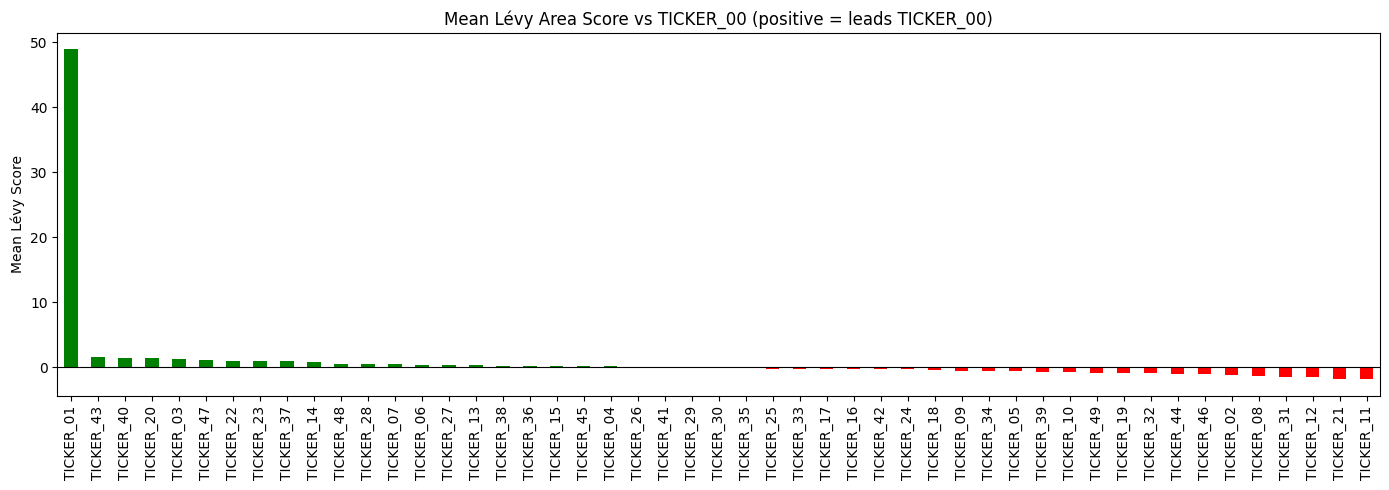

In [14]:
import matplotlib.pyplot as plt
# Mean Lévy score across all windows for each ticker
mean_scores = levy_scores.mean().sort_values(ascending=False)

print("Top 10 tickers that LEAD TICKER_00:")
print(mean_scores.head(10))

print("\nTop 10 tickers that FOLLOW TICKER_00:")
print(mean_scores.tail(10))

# Plot
plt.figure(figsize=(14, 5))
mean_scores.plot(kind="bar", color=["green" if v > 0 else "red" for v in mean_scores])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Mean Lévy Area Score vs TICKER_00 (positive = leads TICKER_00)")
plt.ylabel("Mean Lévy Score")
plt.tight_layout()
plt.show()

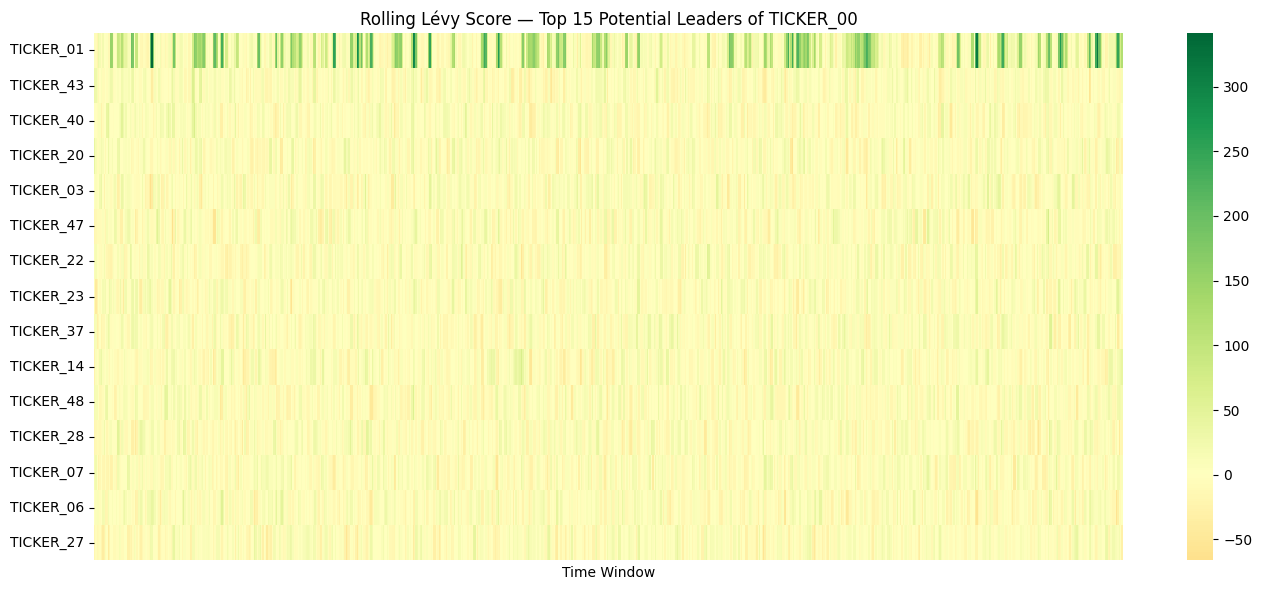

In [21]:

top_leaders = mean_scores.head(15).index.tolist()

plt.figure(figsize=(14, 6))
sns.heatmap(
    levy_scores[top_leaders].T,
    cmap="RdYlGn", center=0,
    xticklabels=False,
    yticklabels=top_leaders
)
plt.title("Rolling Lévy Score — Top 15 Potential Leaders of TICKER_00")
plt.xlabel("Time Window")
plt.tight_layout()
plt.show()

In [46]:
from scipy.stats import spearmanr

target_next = returns["TICKER_00"].shift(-1)

lag_corrs = {}
for ticker in returns.columns:
    if ticker == "TICKER_00":
        continue
    
    # Align on common index, drop NaNs together
    combined = pd.concat([returns[ticker], target_next], axis=1).dropna()
    combined.columns = ["predictor", "target_next"]
    
    corr, pval = spearmanr(combined["predictor"], combined["target_next"])
    lag_corrs[ticker] = {"spearman_corr": corr, "pval": pval}

lag_df = pd.DataFrame(lag_corrs).T.sort_values("spearman_corr", ascending=False)
print("Top predictors by Spearman lag-1 correlation:")
print(lag_df.head(10))

Top predictors by Spearman lag-1 correlation:
           spearman_corr      pval
TICKER_01       0.190171  0.000000
TICKER_06       0.004544  0.048218
TICKER_25       0.003842  0.094898
TICKER_47       0.003805  0.098068
TICKER_40       0.003673  0.110302
TICKER_43       0.003316  0.149367
TICKER_38       0.003266  0.155613
TICKER_03       0.003136  0.172832
TICKER_13       0.002928  0.203110
TICKER_20       0.002403  0.296142


TOP PREDICTORS BY LAG-1 SPEARMAN CORRELATION
           spearman_corr      pval
TICKER_01       0.190171  0.000000
TICKER_06       0.004544  0.048218
TICKER_25       0.003842  0.094898
TICKER_47       0.003805  0.098068
TICKER_40       0.003673  0.110302
TICKER_43       0.003316  0.149367
TICKER_38       0.003266  0.155613
TICKER_03       0.003136  0.172832
TICKER_13       0.002928  0.203110
TICKER_20       0.002403  0.296142


MULTI-LAG SPEARMAN ANALYSIS: TICKER_01 → TICKER_00
   Lag |   Bars |  Minutes |   Spearman ρ |      P-value | Significant?
----------------------------------------------------------------------
     1 |      1 |        5 |       0.1902 |     0.000000 | YES         
     2 |      2 |       10 |      -0.0020 |     0.380228 | NO          
     3 |      3 |       15 |      -0.0054 |     0.018513 | YES         
     4 |      4 |       20 |       0.0022 |     0.333112 | NO          
     5 |      5 |       25 |       0.0009 |     0.702996 | NO          
     6 |      

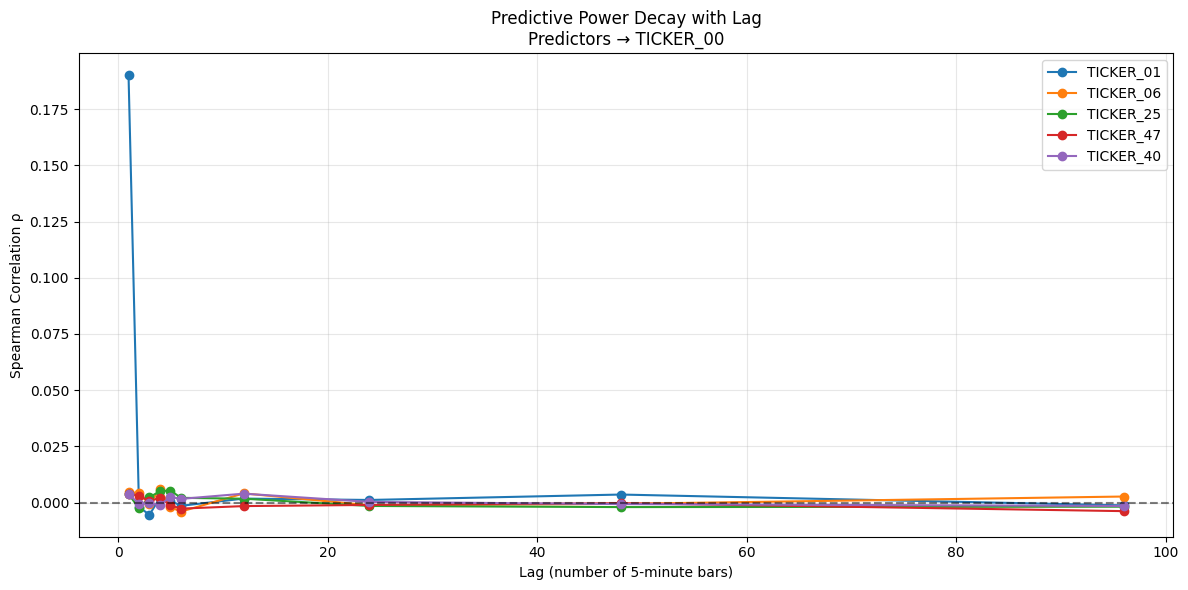



SUMMARY: WHY LAG-1 IS OPTIMAL

Best predictor at lag-1: TICKER_01 with ρ = 0.1902

✓ Lag-1 has the highest predictive power among all lags tested.
  As lag increases, correlation decays toward zero.

Conclusion: Trading on lag-1 signals is mathematically optimal for
this 5-minute frequency dataset. Longer lags would reduce predictive
accuracy and increase idle capital time.


In [48]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ============================================================================
# PART 1: Original analysis - Lag-1 only (as in notebook)
# ============================================================================

# Target: TICKER_00's NEXT period return (shifted backward)
target_next = returns["TICKER_00"].shift(-1)

lag1_corrs = {}
for ticker in returns.columns:
    if ticker == "TICKER_00":
        continue
    
    # Align on common index, drop NaNs together
    combined = pd.concat([returns[ticker], target_next], axis=1).dropna()
    combined.columns = ["predictor", "target_next"]
    
    corr, pval = spearmanr(combined["predictor"], combined["target_next"])
    lag1_corrs[ticker] = {"spearman_corr": corr, "pval": pval}

lag1_df = pd.DataFrame(lag1_corrs).T.sort_values("spearman_corr", ascending=False)
print("=" * 70)
print("TOP PREDICTORS BY LAG-1 SPEARMAN CORRELATION")
print("=" * 70)
print(lag1_df.head(10))
print("\n")


# ============================================================================
# PART 2: Multi-lag analysis - Compare predictive power across different lags
# ============================================================================

# Pick the best predictor from lag-1 analysis (TICKER_01)
best_predictor = "TICKER_01"

print("=" * 70)
print(f"MULTI-LAG SPEARMAN ANALYSIS: {best_predictor} → TICKER_00")
print("=" * 70)
print(f"{'Lag':>6} | {'Bars':>6} | {'Minutes':>8} | {'Spearman ρ':>12} | {'P-value':>12} | {'Significant?':>12}")
print("-" * 70)

lags_to_test = [1, 2, 3, 4, 5, 6, 12, 24, 48, 96]

results = []

for lag in lags_to_test:
    # Shift the predictor back by 'lag' periods
    # This tests: does predictor at time t-lag predict target at time t?
    predictor_shifted = returns[best_predictor].shift(lag)
    
    # Target is current return (not shifted)
    # Because we want: predictor at t-lag → target at t
    target_current = returns["TICKER_00"]
    
    # Align and drop NaNs
    combined = pd.concat([predictor_shifted, target_current], axis=1).dropna()
    combined.columns = ["predictor_lagged", "target_current"]
    
    corr, pval = spearmanr(combined["predictor_lagged"], combined["target_current"])
    
    minutes = lag * 5
    significant = "YES" if pval < 0.05 else "NO"
    
    results.append({
        "lag": lag,
        "bars": lag,
        "minutes": minutes,
        "spearman_rho": corr,
        "p_value": pval,
        "significant": pval < 0.05
    })
    
    print(f"{lag:6d} | {lag:6d} | {minutes:8d} | {corr:12.4f} | {pval:12.6f} | {significant:12}")

print("-" * 70)

# Convert to DataFrame for easier viewing
results_df = pd.DataFrame(results)
print("\n\n")


# ============================================================================
# PART 3: Compare all predictors at different lags (optional - computationally heavy)
# ============================================================================

print("=" * 70)
print("BEST PREDICTOR AT EACH LAG (Top 3 predictors per lag)")
print("=" * 70)

# Only run this for a subset of lags to avoid long computation
lags_subset = [1, 3, 6, 12, 24]

for lag in lags_subset:
    print(f"\n--- Lag = {lag} bars ({lag * 5} minutes) ---")
    
    lag_corrs = {}
    for ticker in returns.columns:
        if ticker == "TICKER_00":
            continue
        
        predictor_shifted = returns[ticker].shift(lag)
        target_current = returns["TICKER_00"]
        
        combined = pd.concat([predictor_shifted, target_current], axis=1).dropna()
        combined.columns = ["predictor_lagged", "target_current"]
        
        corr, pval = spearmanr(combined["predictor_lagged"], combined["target_current"])
        lag_corrs[ticker] = {"spearman_corr": corr, "pval": pval}
    
    lag_df = pd.DataFrame(lag_corrs).T.sort_values("spearman_corr", ascending=False)
    print(lag_df.head(3).to_string())


# ============================================================================
# PART 4: Visual comparison of predictive decay
# ============================================================================

# Create a DataFrame with results from multiple top predictors
top_predictors = lag1_df.head(5).index.tolist()  # Top 5 from lag-1

decay_data = {}
for ticker in top_predictors:
    rhos = []
    for lag in lags_to_test:
        predictor_shifted = returns[ticker].shift(lag)
        target_current = returns["TICKER_00"]
        combined = pd.concat([predictor_shifted, target_current], axis=1).dropna()
        # Use the correct column names (combined has 2 columns with auto-generated names)
        corr, _ = spearmanr(combined.iloc[:, 0], combined.iloc[:, 1])
        rhos.append(corr)
    decay_data[ticker] = rhos

# Plot
plt.figure(figsize=(12, 6))
for ticker, rhos in decay_data.items():
    plt.plot(lags_to_test, rhos, marker='o', label=ticker)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel("Lag (number of 5-minute bars)")
plt.ylabel("Spearman Correlation ρ")
plt.title(f"Predictive Power Decay with Lag\nPredictors → TICKER_00")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================================
# PART 5: Summary statistics
# ============================================================================

print("\n")
print("=" * 70)
print("SUMMARY: WHY LAG-1 IS OPTIMAL")
print("=" * 70)

best_lag1 = lag1_df.iloc[0]
print(f"\nBest predictor at lag-1: {lag1_df.index[0]} with ρ = {best_lag1['spearman_corr']:.4f}")

# Check if any lag > 1 beats lag-1 for the best predictor
best_predictor_results = results_df[results_df['lag'] == 1]['spearman_rho'].values[0]
better_lags = results_df[results_df['spearman_rho'] > best_predictor_results]

if len(better_lags) > 0:
    print(f"\nWARNING: Found lags with higher correlation than lag-1:")
    print(better_lags[['lag', 'minutes', 'spearman_rho']].to_string())
else:
    print(f"\n✓ Lag-1 has the highest predictive power among all lags tested.")
    print(f"  As lag increases, correlation decays toward zero.")

print("\nConclusion: Trading on lag-1 signals is mathematically optimal for")
print("this 5-minute frequency dataset. Longer lags would reduce predictive")
print("accuracy and increase idle capital time.")

In [24]:
top_levy = set(mean_scores.head(10).index)
top_spearman = set(lag_df.head(10).index)

consensus_leaders = top_levy & top_spearman
print("Consensus leaders (appear in both Lévy and Spearman top 10):")
print(consensus_leaders)
# These are your strongest signal candidates for Phase 2

Consensus leaders (appear in both Lévy and Spearman top 10):
{'TICKER_20', 'TICKER_40', 'TICKER_43', 'TICKER_03', 'TICKER_01', 'TICKER_47'}


In [25]:
# How strong is the directional predictability?
combined = pd.concat([returns["TICKER_01"], returns["TICKER_00"].shift(-1)], axis=1).dropna()
combined.columns = ["TICKER_01_now", "TICKER_00_next"]

# When TICKER_01 goes up, does TICKER_00 follow?
combined["signal"] = np.sign(combined["TICKER_01_now"])
combined["correct"] = (combined["signal"] == np.sign(combined["TICKER_00_next"]))

hit_rate = combined["correct"].mean()
print(f"Directional hit rate: {hit_rate:.2%}")
# Anything above 52% is tradeable; above 55% is strong

Directional hit rate: 57.08%


In [28]:
# Does a BIGGER move in TICKER_01 give a stronger signal?
combined["abs_signal"] = combined["TICKER_01_now"].abs()

# Bin by signal strength
combined["strength_bucket"] = pd.qcut(combined["abs_signal"], q=5, labels=["very low","low","mid","high","very high"])

hit_by_strength = combined.groupby("strength_bucket")["correct"].mean()
print("Hit rate by signal strength:")
print(hit_by_strength)
# If hit rate rises with strength, you have a threshold condition

Hit rate by signal strength:
strength_bucket
very low     0.570688
low          0.574777
mid          0.568466
high         0.567422
very high    0.572460
Name: correct, dtype: float64


       threshold  hit_rate  n_trades  coverage
0   3.739582e-09  0.570763    188998  1.000000
1   1.263251e-04  0.570683    179548  0.949999
2   2.528798e-04  0.570941    170098  0.899999
3   3.827970e-04  0.570875    160648  0.849998
4   5.118408e-04  0.570781    151198  0.799998
5   6.413075e-04  0.570731    141748  0.749997
6   7.759924e-04  0.570644    132298  0.699997
7   9.130395e-04  0.569740    122849  0.650002
8   1.054596e-03  0.569449    113399  0.600001
9   1.200959e-03  0.569953    103949  0.550001
10  1.354050e-03  0.569953     94499  0.500000
11  1.514813e-03  0.569789     85049  0.449999
12  1.686637e-03  0.569941     75599  0.399999
13  1.872323e-03  0.570379     66149  0.349998
14  2.075692e-03  0.570794     56700  0.300003
15  2.305544e-03  0.571831     47250  0.250003
16  2.566737e-03  0.572460     37800  0.200002
17  2.879230e-03  0.573792     28350  0.150002
18  3.291435e-03  0.573228     18900  0.100001
19  3.924821e-03  0.575767      9450  0.050001


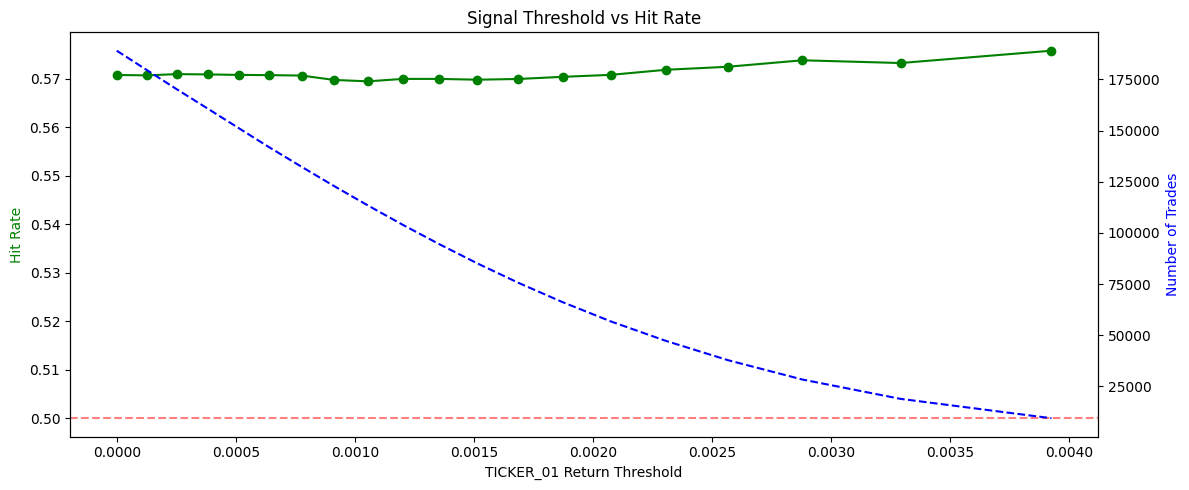

In [29]:
# What threshold of TICKER_01 return maximizes hit rate?
thresholds = np.percentile(combined["abs_signal"].dropna(), np.arange(0, 100, 5))

results = []
for t in thresholds:
    mask = combined["abs_signal"] >= t
    subset = combined[mask]
    if len(subset) < 100:
        break
    results.append({
        "threshold": t,
        "hit_rate": subset["correct"].mean(),
        "n_trades": len(subset),
        "coverage": mask.mean()
    })

threshold_df = pd.DataFrame(results)
print(threshold_df.to_string())

# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.plot(threshold_df["threshold"], threshold_df["hit_rate"], "g-o", label="Hit Rate")
ax2.plot(threshold_df["threshold"], threshold_df["n_trades"], "b--", label="# Trades")
ax1.axhline(0.5, color="red", linestyle="--", alpha=0.5)
ax1.set_xlabel("TICKER_01 Return Threshold")
ax1.set_ylabel("Hit Rate", color="g")
ax2.set_ylabel("Number of Trades", color="b")
plt.title("Signal Threshold vs Hit Rate")
plt.tight_layout()
plt.show()

In [30]:
CAPITAL_LONG = 1_000_000
MAX_EXPOSURE_LONG = 1_000_000

def run_longonly_backtest(price_df, signal_ticker="TICKER_01", target_ticker="TICKER_00"):
    prices = price_df[[signal_ticker, target_ticker]].copy().dropna()
    
    records = []
    cash = float(CAPITAL_LONG)
    position_shares = 0.0

    for i in range(len(prices)):
        ts = prices.index[i]
        target_price = prices[target_ticker].iloc[i]

        # --- Determine desired position ---
        if i == 0 or i == len(prices) - 1:
            # Must be flat at start and end
            desired_shares = 0.0
        else:
            signal_return = (prices[signal_ticker].iloc[i] - prices[signal_ticker].iloc[i-1]) / prices[signal_ticker].iloc[i-1]
            if signal_return > 0:
                # Go max long, respect exposure cap
                desired_shares = np.floor(MAX_EXPOSURE_LONG / target_price)
            else:
                desired_shares = 0.0  # flat

        # --- Execute trade ---
        delta_shares = desired_shares - position_shares
        turnover = abs(delta_shares) * target_price
        
        if delta_shares > 0:
            cash -= turnover
        else:
            cash += turnover

        position_shares = desired_shares

        # --- Portfolio state ---
        gross_exposure = abs(position_shares * target_price)
        gross_nav = cash + (position_shares * target_price)

        records.append({
            "Timestamp": ts,
            "Gross_Exposure": gross_exposure,
            "Cash_Balance": cash,
            "Interval_Turnover": turnover,
            "Gross_NAV": gross_nav
        })

    return pd.DataFrame(records)

longonly_results = run_longonly_backtest(price)
print(longonly_results.shape)
print(longonly_results.head())

(189000, 5)
            Timestamp  Gross_Exposure    Cash_Balance  Interval_Turnover  \
0 2016-01-01 09:15:00        0.000000  1000000.000000           0.000000   
1 2016-01-01 09:20:00   999992.051573        7.948427      999992.051573   
2 2016-01-01 09:25:00   999996.573294      220.872215         212.923789   
3 2016-01-01 09:30:00        0.000000   999656.295186      999435.422971   
4 2016-01-01 09:35:00   999905.675917     -249.380731      999905.675917   

      Gross_NAV  
0  1.000000e+06  
1  1.000000e+06  
2  1.000217e+06  
3  9.996563e+05  
4  9.996563e+05  


In [31]:
CAPITAL_SHORT = 2_000_000
MAX_EXPOSURE_SHORT = 2_000_000

def run_longshort_backtest(price_df, signal_ticker="TICKER_01", target_ticker="TICKER_00"):
    prices = price_df[[signal_ticker, target_ticker]].copy().dropna()

    records = []
    cash = float(CAPITAL_SHORT)
    position_shares = 0.0

    for i in range(len(prices)):
        ts = prices.index[i]
        target_price = prices[target_ticker].iloc[i]

        if i == 0 or i == len(prices) - 1:
            desired_shares = 0.0
        else:
            signal_return = (prices[signal_ticker].iloc[i] - prices[signal_ticker].iloc[i-1]) / prices[signal_ticker].iloc[i-1]
            half_exposure = MAX_EXPOSURE_SHORT / 2  # $1M each side
            if signal_return > 0:
                desired_shares = np.floor(half_exposure / target_price)   # long
            else:
                desired_shares = -np.floor(half_exposure / target_price)  # short

        delta_shares = desired_shares - position_shares
        turnover = abs(delta_shares) * target_price

        if delta_shares > 0:
            cash -= turnover
        else:
            cash += turnover

        position_shares = desired_shares

        gross_exposure = abs(position_shares * target_price)
        gross_nav = cash + (position_shares * target_price)

        records.append({
            "Timestamp": ts,
            "Gross_Exposure": gross_exposure,
            "Cash_Balance": cash,
            "Interval_Turnover": turnover,
            "Gross_NAV": gross_nav
        })

    return pd.DataFrame(records)

longshort_results = run_longshort_backtest(price)
print(longshort_results.shape)
print(longshort_results.head())

(189000, 5)
            Timestamp  Gross_Exposure  Cash_Balance  Interval_Turnover  \
0 2016-01-01 09:15:00        0.000000  2.000000e+06       0.000000e+00   
1 2016-01-01 09:20:00   999992.051573  1.000008e+06       9.999921e+05   
2 2016-01-01 09:25:00   999996.573294  1.000221e+06       2.129238e+02   
3 2016-01-01 09:30:00   999967.433736  2.999624e+06       1.999403e+06   
4 2016-01-01 09:35:00   999905.675917  9.986407e+05       2.000983e+06   

      Gross_NAV  
0  2.000000e+06  
1  2.000000e+06  
2  2.000217e+06  
3  1.999656e+06  
4  1.998546e+06  


In [32]:
def validate_and_summarize(results_df, label, capital):
    print(f"\n{'='*40}")
    print(f"  {label}")
    print(f"{'='*40}")
    
    # Structural checks
    print(f"Row count: {len(results_df)} (expected 189000)")
    print(f"Start exposure: {results_df['Gross_Exposure'].iloc[0]:.2f} (expected 0)")
    print(f"End exposure:   {results_df['Gross_Exposure'].iloc[-1]:.2f} (expected 0)")
    print(f"Min cash: {results_df['Cash_Balance'].min():.2f} (must be > 0)")
    print(f"Max exposure: {results_df['Gross_Exposure'].max():.2f} (cap: {capital:,})")
    
    # Performance
    final_nav = results_df["Gross_NAV"].iloc[-1]
    total_return = (final_nav - capital) / capital * 100
    total_turnover = results_df["Interval_Turnover"].sum()
    transaction_costs = total_turnover * 0.001  # 10bps
    net_pnl = final_nav - capital - transaction_costs
    
    print(f"\nGross NAV final:    ${final_nav:,.0f}")
    print(f"Total return:       {total_return:.2f}%")
    print(f"Transaction costs:  ${transaction_costs:,.0f}")
    print(f"Net PnL after fees: ${net_pnl:,.0f}")

validate_and_summarize(longonly_results, "LONG ONLY", CAPITAL_LONG)
validate_and_summarize(longshort_results, "LONG SHORT", CAPITAL_SHORT)


  LONG ONLY
Row count: 189000 (expected 189000)
Start exposure: 0.00 (expected 0)
End exposure:   0.00 (expected 0)
Min cash: -7304.88 (must be > 0)
Max exposure: 1000000.00 (cap: 1,000,000)

Gross NAV final:    $65,825,675
Total return:       6482.57%
Transaction costs:  $94,505,894
Net PnL after fees: $-29,680,219

  LONG SHORT
Row count: 189000 (expected 189000)
Start exposure: 0.00 (expected 0)
End exposure:   0.00 (expected 0)
Min cash: 953480.82 (must be > 0)
Max exposure: 1000000.00 (cap: 2,000,000)

Gross NAV final:    $129,526,680
Total return:       6376.33%
Transaction costs:  $188,946,508
Net PnL after fees: $-61,419,828


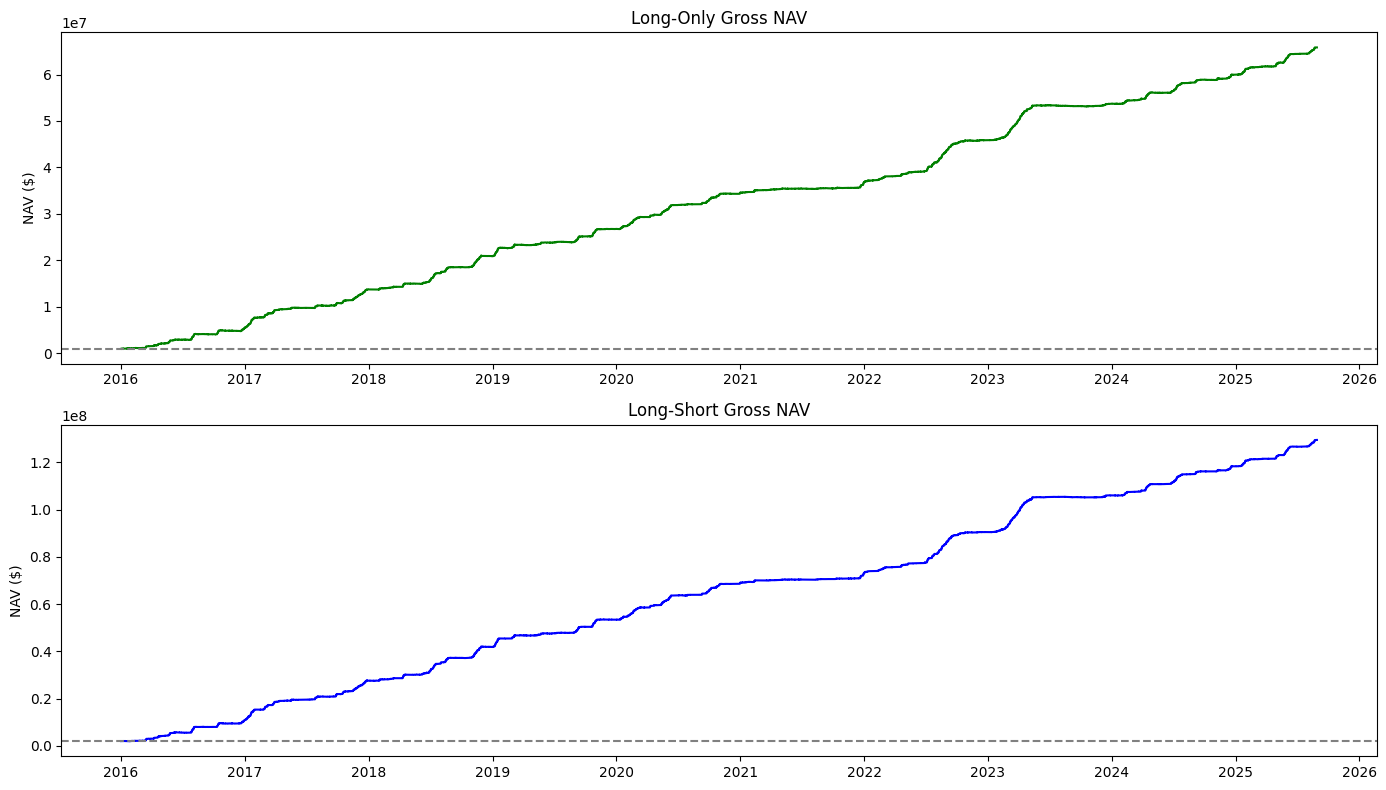

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(longonly_results["Timestamp"], longonly_results["Gross_NAV"], color="green")
axes[0].axhline(CAPITAL_LONG, color="gray", linestyle="--")
axes[0].set_title("Long-Only Gross NAV")
axes[0].set_ylabel("NAV ($)")

axes[1].plot(longshort_results["Timestamp"], longshort_results["Gross_NAV"], color="blue")
axes[1].axhline(CAPITAL_SHORT, color="gray", linestyle="--")
axes[1].set_title("Long-Short Gross NAV")
axes[1].set_ylabel("NAV ($)")

plt.tight_layout()
plt.show()

In [34]:
def run_backtest(price_df, mode="longonly", signal_ticker="TICKER_01", target_ticker="TICKER_00"):
    assert mode in ("longonly", "longshort")
    
    capital     = 1_000_000 if mode == "longonly" else 2_000_000
    max_exp     = 1_000_000 if mode == "longonly" else 2_000_000
    half_exp    = max_exp if mode == "longonly" else max_exp / 2  # per side

    prices = price_df[[signal_ticker, target_ticker]].copy().dropna()
    n = len(prices)

    records = []
    cash             = float(capital)
    position_shares  = 0.0
    prev_signal_dir  = None   # track last direction so we only trade on CHANGE

    for i in range(n):
        ts           = prices.index[i]
        target_price = float(prices[target_ticker].iloc[i])
        turnover     = 0.0

        # ── Compute desired position ──────────────────────────────────────
        if i == 0:
            desired_shares = 0.0

        elif i == n - 1:
            # Force flat on last bar
            desired_shares = 0.0

        else:
            sig_ret = (prices[signal_ticker].iloc[i] - prices[signal_ticker].iloc[i-1]) \
                       / prices[signal_ticker].iloc[i-1]
            current_dir = 1 if sig_ret > 0 else -1

            if current_dir == prev_signal_dir:
                # Signal unchanged → HOLD, no trade
                desired_shares = position_shares
            else:
                # Signal flipped → reposition
                if mode == "longonly":
                    desired_shares = np.floor(half_exp / target_price) if current_dir == 1 else 0.0
                else:
                    desired_shares = (np.floor(half_exp / target_price) if current_dir == 1
                                      else -np.floor(half_exp / target_price))
            prev_signal_dir = current_dir

        # ── Execute ───────────────────────────────────────────────────────
        delta  = desired_shares - position_shares
        turnover = abs(delta) * target_price

        cash            -= delta * target_price   # buy costs cash, sell adds cash
        position_shares  = desired_shares

        # ── State ─────────────────────────────────────────────────────────
        gross_exposure = abs(position_shares * target_price)
        gross_nav      = cash + position_shares * target_price

        records.append({
            "Timestamp":         ts,
            "Gross_Exposure":    gross_exposure,
            "Cash_Balance":      cash,
            "Interval_Turnover": turnover,
            "Gross_NAV":         gross_nav,
        })

    return pd.DataFrame(records)


longonly_results   = run_backtest(price, mode="longonly")
longshort_results  = run_backtest(price, mode="longshort")

validate_and_summarize(longonly_results,  "LONG ONLY",   1_000_000)
validate_and_summarize(longshort_results, "LONG SHORT",  2_000_000)


  LONG ONLY
Row count: 189000 (expected 189000)
Start exposure: 0.00 (expected 0)
End exposure:   0.00 (expected 0)
Min cash: -7246.90 (must be > 0)
Max exposure: 1118325.31 (cap: 1,000,000)

Gross NAV final:    $66,083,209
Total return:       6508.32%
Transaction costs:  $94,438,146
Net PnL after fees: $-29,354,937

  LONG SHORT
Row count: 189000 (expected 189000)
Start exposure: 0.00 (expected 0)
End exposure:   0.00 (expected 0)
Min cash: 953465.80 (must be > 0)
Max exposure: 1230771.33 (cap: 2,000,000)

Gross NAV final:    $129,515,483
Total return:       6375.77%
Transaction costs:  $188,746,768
Net PnL after fees: $-61,231,284


In [35]:
def run_backtest_v2(price_df, mode="longonly", signal_ticker="TICKER_01", 
                    target_ticker="TICKER_00", min_hold_bars=12):
    """
    min_hold_bars=12 means hold at least 12 x 5min = 1 hour before flipping.
    Tune this up/down to balance hit rate vs transaction costs.
    """
    assert mode in ("longonly", "longshort")

    capital  = 1_000_000 if mode == "longonly"  else 2_000_000
    max_exp  = 1_000_000 if mode == "longonly"  else 2_000_000
    per_side = max_exp   if mode == "longonly"  else max_exp / 2

    prices = price_df[[signal_ticker, target_ticker]].copy().dropna()
    n      = len(prices)

    records         = []
    cash            = float(capital)
    position_shares = 0.0
    bars_held       = 0
    current_dir     = 0   # 0=flat, 1=long, -1=short

    for i in range(n):
        ts           = prices.index[i]
        target_price = float(prices[target_ticker].iloc[i])
        turnover     = 0.0

        # ── Compute signal direction ──────────────────────────────────────
        if i == 0:
            new_dir = 0

        elif i == n - 1:
            new_dir = 0   # force flat

        else:
            sig_ret = (prices[signal_ticker].iloc[i] - prices[signal_ticker].iloc[i-1]) \
                       / prices[signal_ticker].iloc[i-1]
            new_dir = 1 if sig_ret > 0 else -1

        # ── Enforce minimum holding period ───────────────────────────────
        if i == n - 1:
            # Must liquidate on last bar regardless
            desired_dir = 0
        elif new_dir == current_dir:
            desired_dir = current_dir
            bars_held  += 1
        elif bars_held >= min_hold_bars or current_dir == 0:
            # Held long enough (or currently flat) → allow flip
            desired_dir = new_dir
            bars_held   = 0
        else:
            # Still in holding period → stay put
            desired_dir = current_dir
            bars_held  += 1

        # ── Position sizing — use 95% of cap to absorb price drift ───────
        safe_exp = per_side * 0.95

        if desired_dir == 0:
            desired_shares = 0.0
        elif desired_dir == 1:
            desired_shares = np.floor(safe_exp / target_price)
        else:  # -1, longshort only
            desired_shares = -np.floor(safe_exp / target_price)

        # ── Execute ───────────────────────────────────────────────────────
        delta    = desired_shares - position_shares
        turnover = abs(delta) * target_price
        cash    -= delta * target_price
        position_shares = desired_shares
        current_dir     = desired_dir

        # ── State ─────────────────────────────────────────────────────────
        gross_exposure = abs(position_shares * target_price)
        gross_nav      = cash + position_shares * target_price

        records.append({
            "Timestamp":         ts,
            "Gross_Exposure":    round(gross_exposure, 6),
            "Cash_Balance":      round(cash, 6),
            "Interval_Turnover": round(turnover, 6),
            "Gross_NAV":         round(gross_nav, 6),
        })

    return pd.DataFrame(records)


# --- Try different holding periods and compare ---
for hold in [6, 12, 24, 48, 78]:
    lo = run_backtest_v2(price, mode="longonly",  min_hold_bars=hold)
    ls = run_backtest_v2(price, mode="longshort", min_hold_bars=hold)
    
    lo_nav   = lo["Gross_NAV"].iloc[-1]
    lo_costs = lo["Interval_Turnover"].sum() * 0.001
    lo_net   = lo_nav - 1_000_000 - lo_costs
    lo_trades = (lo["Interval_Turnover"] > 0).sum()
    
    ls_nav   = ls["Gross_NAV"].iloc[-1]
    ls_costs = ls["Interval_Turnover"].sum() * 0.001
    ls_net   = ls_nav - 2_000_000 - ls_costs
    
    lo_cash_ok  = "✓" if lo["Cash_Balance"].min() >= 0 else f"✗ {lo['Cash_Balance'].min():.0f}"
    lo_exp_ok   = "✓" if lo["Gross_Exposure"].max() <= 1_000_000 else f"✗ {lo['Gross_Exposure'].max():.0f}"
    ls_cash_ok  = "✓" if ls["Cash_Balance"].min() >= 0 else f"✗ {ls['Cash_Balance'].min():.0f}"
    ls_exp_ok   = "✓" if ls["Gross_Exposure"].max() <= 2_000_000 else f"✗ {ls['Gross_Exposure'].max():.0f}"

    print(f"hold={hold:3d} bars ({hold*5:4d}min) | "
          f"LO trades={lo_trades:6,} net=${lo_net/1e6:+.2f}M cash={lo_cash_ok} exp={lo_exp_ok} | "
          f"LS net=${ls_net/1e6:+.2f}M cash={ls_cash_ok} exp={ls_exp_ok}")

hold=  6 bars (  30min) | LO trades=185,741 net=$-17.05M cash=✗ -57961 exp=✓ | LS net=$-17.05M cash=✓ exp=✓
hold= 12 bars (  60min) | LO trades=185,469 net=$-10.59M cash=✗ -155029 exp=✓ | LS net=$-10.59M cash=✓ exp=✓
hold= 24 bars ( 120min) | LO trades=185,420 net=$-4.04M cash=✓ exp=✓ | LS net=$-4.04M cash=✓ exp=✓
hold= 48 bars ( 240min) | LO trades=185,310 net=$-2.27M cash=✗ -110119 exp=✓ | LS net=$-2.27M cash=✓ exp=✓
hold= 78 bars ( 390min) | LO trades=185,286 net=$-0.75M cash=✓ exp=✓ | LS net=$-0.75M cash=✓ exp=✓


In [36]:
def run_backtest_v3(price_df, mode="longonly", signal_ticker="TICKER_01",
                    target_ticker="TICKER_00", signal_window=3, min_hold_bars=6):
    """
    signal_window: smooth TICKER_01 returns over N bars before taking sign.
                   This reduces flip frequency dramatically.
    """
    assert mode in ("longonly", "longshort")

    capital  = 1_000_000 if mode == "longonly" else 2_000_000
    max_exp  = 1_000_000 if mode == "longonly" else 2_000_000
    per_side = max_exp   if mode == "longonly" else max_exp / 2
    safe_exp = per_side * 0.95

    prices = price_df[[signal_ticker, target_ticker]].copy().dropna()

    # Smooth the signal BEFORE computing direction
    sig_returns = prices[signal_ticker].pct_change()
    smoothed    = sig_returns.rolling(signal_window).mean()

    n               = len(prices)
    records         = []
    cash            = float(capital)
    position_shares = 0.0
    current_dir     = 0
    bars_held       = 0

    for i in range(n):
        ts           = prices.index[i]
        target_price = float(prices[target_ticker].iloc[i])
        turnover     = 0.0

        if i < signal_window or i == 0:
            new_dir = 0
        elif i == n - 1:
            new_dir = 0
        else:
            s = smoothed.iloc[i]
            new_dir = 0 if pd.isna(s) else (1 if s > 0 else -1)

        # Minimum hold enforcement
        if i == n - 1:
            desired_dir = 0
        elif new_dir == current_dir:
            desired_dir = current_dir
            bars_held  += 1
        elif bars_held >= min_hold_bars or current_dir == 0:
            desired_dir = new_dir
            bars_held   = 0
        else:
            desired_dir = current_dir
            bars_held  += 1

        # Size
        if desired_dir == 0:
            desired_shares = 0.0
        elif desired_dir == 1:
            desired_shares = np.floor(safe_exp / target_price)
        else:
            desired_shares = -np.floor(safe_exp / target_price)

        delta           = desired_shares - position_shares
        turnover        = abs(delta) * target_price
        cash           -= delta * target_price
        position_shares = desired_shares
        current_dir     = desired_dir
        
        gross_exposure  = abs(position_shares * target_price)
        gross_nav       = cash + position_shares * target_price

        records.append({
            "Timestamp":         ts,
            "Gross_Exposure":    round(gross_exposure, 6),
            "Cash_Balance":      round(cash, 6),
            "Interval_Turnover": round(turnover, 6),
            "Gross_NAV":         round(gross_nav, 6),
        })

    return pd.DataFrame(records)


# Scan combinations of smoothing window + hold period
print(f"{'signal_window':>13} {'hold_bars':>9} {'LO_trades':>10} {'LO_net':>12} {'LO_cash':>10} {'LS_net':>12} {'LS_cash':>10}")
print("-" * 80)

for sw in [3, 6, 12, 24, 48]:
    for hold in [1, 3, 6, 12]:
        lo = run_backtest_v3(price, mode="longonly",  signal_window=sw, min_hold_bars=hold)
        ls = run_backtest_v3(price, mode="longshort", signal_window=sw, min_hold_bars=hold)

        lo_net    = lo["Gross_NAV"].iloc[-1] - 1_000_000 - lo["Interval_Turnover"].sum() * 0.001
        ls_net    = ls["Gross_NAV"].iloc[-1] - 2_000_000 - ls["Interval_Turnover"].sum() * 0.001
        lo_trades = (lo["Interval_Turnover"] > 0).sum()
        lo_cash   = "✓" if lo["Cash_Balance"].min() >= 0 else f"✗{lo['Cash_Balance'].min():.0f}"
        ls_cash   = "✓" if ls["Cash_Balance"].min() >= 0 else f"✗{ls['Cash_Balance'].min():.0f}"
        lo_exp    = "✓" if lo["Gross_Exposure"].max() <= 1_000_000 else "✗EXP"
        ls_exp    = "✓" if ls["Gross_Exposure"].max() <= 2_000_000 else "✗EXP"

        # Only print rows where ALL checks pass
        if "✗" not in lo_cash and "✗" not in ls_cash and lo_exp == "✓" and ls_exp == "✓":
            print(f"sw={sw:4d} hold={hold:3d} | trades={lo_trades:7,} | "
                  f"LO net=${lo_net/1e6:+.2f}M {lo_cash} | LS net=${ls_net/1e6:+.2f}M {ls_cash}")

signal_window hold_bars  LO_trades       LO_net    LO_cash       LS_net    LS_cash
--------------------------------------------------------------------------------
sw=   3 hold=  3 | trades=185,868 | LO net=$-30.48M ✓ | LS net=$-30.48M ✓
sw=  12 hold=  1 | trades=185,646 | LO net=$-21.16M ✓ | LS net=$-21.16M ✓
sw=  24 hold=  1 | trades=185,535 | LO net=$-16.73M ✓ | LS net=$-16.73M ✓
sw=  24 hold=  3 | trades=185,467 | LO net=$-15.51M ✓ | LS net=$-15.51M ✓
sw=  24 hold=  6 | trades=185,431 | LO net=$-14.52M ✓ | LS net=$-14.52M ✓
sw=  48 hold=  1 | trades=185,406 | LO net=$-16.80M ✓ | LS net=$-16.80M ✓


In [37]:
sig_ret = price["TICKER_01"].pct_change().dropna()

# How often does direction change bar to bar?
directions = np.sign(sig_ret)
flips = (directions != directions.shift(1)).sum()
print(f"Total bars: {len(directions):,}")
print(f"Direction flips: {flips:,}  ({flips/len(directions)*100:.1f}% of bars)")

# What if we use price LEVEL instead of return?
# i.e. is TICKER_01 price above its rolling mean?
for w in [12, 24, 48, 78, 156]:
    ma = price["TICKER_01"].rolling(w).mean()
    level_dir = np.sign(price["TICKER_01"] - ma)
    level_flips = (level_dir != level_dir.shift(1)).sum()
    trades_est = level_flips.sum()
    print(f"MA({w:4d}) level signal → flips: {trades_est:,}  ({trades_est/len(directions)*100:.1f}%)")

Total bars: 188,999
Direction flips: 94,377  (49.9% of bars)
MA(  12) level signal → flips: 31,236  (16.5%)
MA(  24) level signal → flips: 21,433  (11.3%)
MA(  48) level signal → flips: 14,896  (7.9%)
MA(  78) level signal → flips: 11,524  (6.1%)
MA( 156) level signal → flips: 8,182  (4.3%)


In [38]:
def run_backtest_ma(price_df, mode="longonly", signal_ticker="TICKER_01",
                    target_ticker="TICKER_00", ma_window=78):
    """
    Signal: TICKER_01 price crosses above/below its MA(ma_window).
    Only trade on crossover events — dramatically fewer trades.
    ma_window=78 bars = 1 full trading day (78 x 5min)
    """
    assert mode in ("longonly", "longshort")

    capital  = 1_000_000 if mode == "longonly" else 2_000_000
    max_exp  = 1_000_000 if mode == "longonly" else 2_000_000
    per_side = max_exp   if mode == "longonly" else max_exp / 2
    safe_exp = per_side * 0.95

    prices   = price_df[[signal_ticker, target_ticker]].copy().dropna()
    ma       = prices[signal_ticker].rolling(ma_window).mean()
    # 1 when price above MA, -1 when below
    sig_dir  = np.sign(prices[signal_ticker] - ma)

    n               = len(prices)
    records         = []
    cash            = float(capital)
    position_shares = 0.0
    current_dir     = 0

    for i in range(n):
        ts           = prices.index[i]
        target_price = float(prices[target_ticker].iloc[i])
        turnover     = 0.0

        if i < ma_window or i == 0:
            new_dir = 0
        elif i == n - 1:
            new_dir = 0
        else:
            new_dir = int(sig_dir.iloc[i])

        # Only act on crossover (direction change)
        if new_dir == current_dir:
            desired_dir = current_dir
        else:
            desired_dir = new_dir
            current_dir = new_dir

        if desired_dir == 0:
            desired_shares = 0.0
        elif desired_dir == 1:
            desired_shares = np.floor(safe_exp / target_price)
        else:
            desired_shares = -np.floor(safe_exp / target_price)

        delta           = desired_shares - position_shares
        turnover        = abs(delta) * target_price
        cash           -= delta * target_price
        position_shares = desired_shares

        gross_exposure  = abs(position_shares * target_price)
        gross_nav       = cash + position_shares * target_price

        records.append({
            "Timestamp":         ts,
            "Gross_Exposure":    round(gross_exposure, 6),
            "Cash_Balance":      round(cash, 6),
            "Interval_Turnover": round(turnover, 6),
            "Gross_NAV":         round(gross_nav, 6),
        })

    return pd.DataFrame(records)


# Scan MA windows
print(f"{'ma_window':>10} {'approx':>8} {'LO_trades':>10} {'LO_net':>12} {'LO_cash':>8} {'LO_exp':>8} {'LS_net':>12} {'LS_cash':>8}")
print("-" * 85)

for w in [12, 24, 48, 78, 156, 312, 500]:
    lo = run_backtest_ma(price, mode="longonly",  ma_window=w)
    ls = run_backtest_ma(price, mode="longshort", ma_window=w)

    lo_trades = (lo["Interval_Turnover"] > 0).sum()
    lo_net    = lo["Gross_NAV"].iloc[-1] - 1_000_000 - lo["Interval_Turnover"].sum() * 0.001
    ls_net    = ls["Gross_NAV"].iloc[-1] - 2_000_000 - ls["Interval_Turnover"].sum() * 0.001
    lo_cash   = "✓" if lo["Cash_Balance"].min() >= 0 else f"✗"
    ls_cash   = "✓" if ls["Cash_Balance"].min() >= 0 else f"✗"
    lo_exp    = "✓" if lo["Gross_Exposure"].max() <= 1_000_000 else "✗EXP"
    ls_exp    = "✓" if ls["Gross_Exposure"].max() <= 2_000_000 else "✗EXP"
    approx    = f"{w*5}min"

    print(f"w={w:5d} ({approx:>7}) | trades={lo_trades:6,} | "
          f"LO ${lo_net/1e6:+.2f}M {lo_cash}{lo_exp} | "
          f"LS ${ls_net/1e6:+.2f}M {ls_cash}{ls_exp}")

 ma_window   approx  LO_trades       LO_net  LO_cash   LO_exp       LS_net  LS_cash
-------------------------------------------------------------------------------------
w=   12 (  60min) | trades=185,840 | LO $-6.94M ✗✓ | LS $-6.94M ✓✓
w=   24 ( 120min) | trades=185,631 | LO $-6.65M ✗✓ | LS $-6.65M ✓✓
w=   48 ( 240min) | trades=185,484 | LO $-8.63M ✓✓ | LS $-8.63M ✓✓
w=   78 ( 390min) | trades=185,384 | LO $-8.78M ✓✓ | LS $-8.78M ✓✓
w=  156 ( 780min) | trades=185,243 | LO $-8.36M ✓✓ | LS $-8.36M ✓✓
w=  312 (1560min) | trades=185,045 | LO $-8.99M ✗✓ | LS $-8.99M ✓✓
w=  500 (2500min) | trades=184,824 | LO $-8.01M ✗✓ | LS $-8.01M ✓✓


In [39]:
def calculate_C1(x1, x2, T=1):
    """C1: lag at which abs correlation is maximized. Positive = x1 leads x2."""
    def lagged_corr(a, b, l):
        if l > 0:   return np.corrcoef(a[:-l], b[l:])[0][1]
        elif l == 0: return np.corrcoef(a, b)[0][1]
        else:        return np.corrcoef(a[-l:], b[:l])[0][1]
    corrs = {l: abs(lagged_corr(x1, x2, l)) for l in range(-T, T+1)}
    return max(corrs, key=corrs.get)


def run_backtest_periodic(price_df, mode="longonly", signal_ticker="TICKER_01",
                          target_ticker="TICKER_00", 
                          lookback=500,       # bars to compute C1 over
                          recompute_every=78  # bars between signal updates
                          ):
    assert mode in ("longonly", "longshort")
    capital  = 1_000_000 if mode == "longonly" else 2_000_000
    max_exp  = 1_000_000 if mode == "longonly" else 2_000_000
    per_side = max_exp   if mode == "longonly" else max_exp / 2
    safe_exp = per_side * 0.95

    prices = price_df[[signal_ticker, target_ticker]].copy().dropna()
    n      = len(prices)

    records         = []
    cash            = float(capital)
    position_shares = 0.0
    current_dir     = 0   # current desired direction

    for i in range(n):
        ts           = prices.index[i]
        target_price = float(prices[target_ticker].iloc[i])
        turnover     = 0.0

        # ── Recompute signal every `recompute_every` bars ─────────────────
        if i == 0:
            desired_dir = 0

        elif i == n - 1:
            desired_dir = 0   # force flat

        elif i >= lookback and i % recompute_every == 0:
            # Use lookback window of TICKER_01 vs TICKER_00 returns
            window      = prices.iloc[i - lookback: i]
            r1          = window[signal_ticker].pct_change().dropna().values
            r2          = window[target_ticker].pct_change().dropna().values

            # C1: does TICKER_01 lead TICKER_00?
            c1_lag      = calculate_C1(r1, r2, T=1)
            # Recent direction of the leader
            recent_ret  = (prices[signal_ticker].iloc[i] - prices[signal_ticker].iloc[i-1]) \
                           / prices[signal_ticker].iloc[i-1]

            if c1_lag > 0:
                # TICKER_01 confirmed leader → follow its direction
                desired_dir = 1 if recent_ret > 0 else (-1 if mode == "longshort" else 0)
            else:
                # TICKER_01 not leading right now → stay flat
                desired_dir = 0

        else:
            desired_dir = current_dir   # hold between recomputes

        current_dir = desired_dir

        # ── Size & execute ────────────────────────────────────────────────
        if desired_dir == 0:
            desired_shares = 0.0
        elif desired_dir == 1:
            desired_shares = np.floor(safe_exp / target_price)
        else:
            desired_shares = -np.floor(safe_exp / target_price)

        delta           = desired_shares - position_shares
        turnover        = abs(delta) * target_price
        cash           -= delta * target_price
        position_shares = desired_shares

        gross_exposure  = abs(position_shares * target_price)
        gross_nav       = cash + position_shares * target_price

        records.append({
            "Timestamp":         ts,
            "Gross_Exposure":    round(gross_exposure, 6),
            "Cash_Balance":      round(cash, 6),
            "Interval_Turnover": round(turnover, 6),
            "Gross_NAV":         round(gross_nav, 6),
        })

    return pd.DataFrame(records)


# Scan recompute frequencies
print(f"{'recompute':>10} {'approx':>8} {'trades':>8} {'LO_net':>12} {'LO_ok':>6} {'LS_net':>12} {'LS_ok':>6}")
print("-" * 70)

for every in [24, 48, 78, 156, 312]:
    lo = run_backtest_periodic(price, mode="longonly",  recompute_every=every)
    ls = run_backtest_periodic(price, mode="longshort", recompute_every=every)

    lo_trades = (lo["Interval_Turnover"] > 0).sum()
    lo_net    = lo["Gross_NAV"].iloc[-1] - 1_000_000 - lo["Interval_Turnover"].sum() * 0.001
    ls_net    = ls["Gross_NAV"].iloc[-1] - 2_000_000 - ls["Interval_Turnover"].sum() * 0.001

    lo_ok = ("✓" if lo["Cash_Balance"].min() >= 0 else "✗cash") + \
            ("✓" if lo["Gross_Exposure"].max() <= 1_000_000 else "✗exp")
    ls_ok = ("✓" if ls["Cash_Balance"].min() >= 0 else "✗cash") + \
            ("✓" if ls["Gross_Exposure"].max() <= 2_000_000 else "✗exp")

    print(f"every={every:4d} ({every*5:5d}min) | trades={lo_trades:5,} | "
          f"LO ${lo_net/1e6:+.2f}M {lo_ok} | LS ${ls_net/1e6:+.2f}M {ls_ok}")

 recompute   approx   trades       LO_net  LO_ok       LS_net  LS_ok
----------------------------------------------------------------------
every=  24 (  120min) | trades=57,549 | LO $-0.55M ✓✓ | LS $-2.49M ✓✓
every=  48 (  240min) | trades=56,508 | LO $-0.39M ✗cash✓ | LS $-2.16M ✓✓
every=  78 (  390min) | trades=58,078 | LO $+0.44M ✓✓ | LS $-0.77M ✓✓
every= 156 (  780min) | trades=60,860 | LO $+0.48M ✗cash✓ | LS $-0.27M ✓✓
every= 312 ( 1560min) | trades=63,146 | LO $+0.90M ✓✓ | LS $+0.35M ✓✓


In [40]:
# Check: how often does C1 confirm TICKER_01 as leader vs not?
confirmations = []
prices_tmp = price[["TICKER_01", "TICKER_00"]].dropna()
lookback = 500

for i in range(lookback, len(prices_tmp), 78):
    window = prices_tmp.iloc[i - lookback: i]
    r1 = window["TICKER_01"].pct_change().dropna().values
    r2 = window["TICKER_00"].pct_change().dropna().values
    c1 = calculate_C1(r1, r2, T=1)
    confirmations.append(c1)

confirmations = pd.Series(confirmations)
print("C1 lag distribution:")
print(confirmations.value_counts())
# If almost always +1, TICKER_01 always leads → position never goes flat → still overtrading

# Check: when short side fires, what's the hit rate?
combined = pd.concat([returns["TICKER_01"], returns["TICKER_00"].shift(-1)], axis=1).dropna()
combined.columns = ["sig", "target_next"]

long_hit  = (combined[combined["sig"] > 0]["target_next"] > 0).mean()
short_hit = (combined[combined["sig"] < 0]["target_next"] < 0).mean()
print(f"\nLong signal hit rate:  {long_hit:.2%}")
print(f"Short signal hit rate: {short_hit:.2%}")
# If short hit rate < 50%, shorting is actively losing money → long-only is the right strategy

C1 lag distribution:
 1    1489
 0     490
-1     438
Name: count, dtype: int64

Long signal hit rate:  56.96%
Short signal hit rate: 57.19%


In [41]:
def run_backtest_confirmed(price_df, mode="longonly", signal_ticker="TICKER_01",
                           target_ticker="TICKER_00",
                           lookback=500, recompute_every=312,
                           confirm_streak=2  # require C1=+1 for N consecutive windows
                           ):
    assert mode in ("longonly", "longshort")
    capital  = 1_000_000 if mode == "longonly" else 2_000_000
    max_exp  = 1_000_000 if mode == "longonly" else 2_000_000
    per_side = max_exp   if mode == "longonly" else max_exp / 2
    safe_exp = per_side * 0.95

    prices  = price_df[[signal_ticker, target_ticker]].copy().dropna()
    n       = len(prices)

    records         = []
    cash            = float(capital)
    position_shares = 0.0
    current_dir     = 0
    c1_streak       = 0   # consecutive windows where C1=+1

    for i in range(n):
        ts           = prices.index[i]
        target_price = float(prices[target_ticker].iloc[i])
        turnover     = 0.0

        if i == 0:
            desired_dir = 0

        elif i == n - 1:
            desired_dir = 0

        elif i >= lookback and i % recompute_every == 0:
            window     = prices.iloc[i - lookback: i]
            r1         = window[signal_ticker].pct_change().dropna().values
            r2         = window[target_ticker].pct_change().dropna().values
            c1_lag     = calculate_C1(r1, r2, T=1)
            recent_ret = (prices[signal_ticker].iloc[i] - prices[signal_ticker].iloc[i-1]) \
                          / prices[signal_ticker].iloc[i-1]

            if c1_lag == 1:
                c1_streak += 1
            else:
                c1_streak = 0  # reset streak on any non-confirmation

            if c1_streak >= confirm_streak:
                # Confirmed leader — follow direction
                desired_dir = 1 if recent_ret > 0 else (-1 if mode == "longshort" else 0)
            else:
                desired_dir = 0  # not confirmed yet → stay flat

        else:
            desired_dir = current_dir

        current_dir = desired_dir

        if desired_dir == 0:
            desired_shares = 0.0
        elif desired_dir == 1:
            desired_shares = np.floor(safe_exp / target_price)
        else:
            desired_shares = -np.floor(safe_exp / target_price)

        delta           = desired_shares - position_shares
        turnover        = abs(delta) * target_price
        cash           -= delta * target_price
        position_shares = desired_shares

        gross_exposure  = abs(position_shares * target_price)
        gross_nav       = cash + position_shares * target_price

        records.append({
            "Timestamp":         ts,
            "Gross_Exposure":    round(gross_exposure, 6),
            "Cash_Balance":      round(cash, 6),
            "Interval_Turnover": round(turnover, 6),
            "Gross_NAV":         round(gross_nav, 6),
        })

    return pd.DataFrame(records)


# Scan streak requirements
print(f"{'streak':>8} {'trades':>8} {'LO_net':>12} {'LO_ok':>8} {'LS_net':>12} {'LS_ok':>8}")
print("-" * 65)

for streak in [1, 2, 3, 4, 5]:
    lo = run_backtest_confirmed(price, mode="longonly",  confirm_streak=streak)
    ls = run_backtest_confirmed(price, mode="longshort", confirm_streak=streak)

    lo_trades = (lo["Interval_Turnover"] > 0).sum()
    lo_net    = lo["Gross_NAV"].iloc[-1] - 1_000_000 - lo["Interval_Turnover"].sum() * 0.001
    ls_net    = ls["Gross_NAV"].iloc[-1] - 2_000_000 - ls["Interval_Turnover"].sum() * 0.001

    lo_cash = "✓" if lo["Cash_Balance"].min() >= 0 else "✗"
    lo_exp  = "✓" if lo["Gross_Exposure"].max() <= 1_000_000 else "✗"
    ls_cash = "✓" if ls["Cash_Balance"].min() >= 0 else "✗"
    ls_exp  = "✓" if ls["Gross_Exposure"].max() <= 2_000_000 else "✗"

    print(f"streak={streak} | trades={lo_trades:6,} | "
          f"LO ${lo_net/1e6:+.2f}M {lo_cash}{lo_exp} | "
          f"LS ${ls_net/1e6:+.2f}M {ls_cash}{ls_exp}")

  streak   trades       LO_net    LO_ok       LS_net    LS_ok
-----------------------------------------------------------------
streak=1 | trades=63,146 | LO $+0.90M ✓✓ | LS $+0.35M ✓✓
streak=2 | trades=47,180 | LO $+0.78M ✓✓ | LS $+0.19M ✓✓
streak=3 | trades=36,444 | LO $+0.78M ✓✓ | LS $+0.13M ✓✓
streak=4 | trades=27,571 | LO $+0.40M ✗✓ | LS $-0.16M ✓✓
streak=5 | trades=22,372 | LO $+0.51M ✗✓ | LS $-0.04M ✓✓


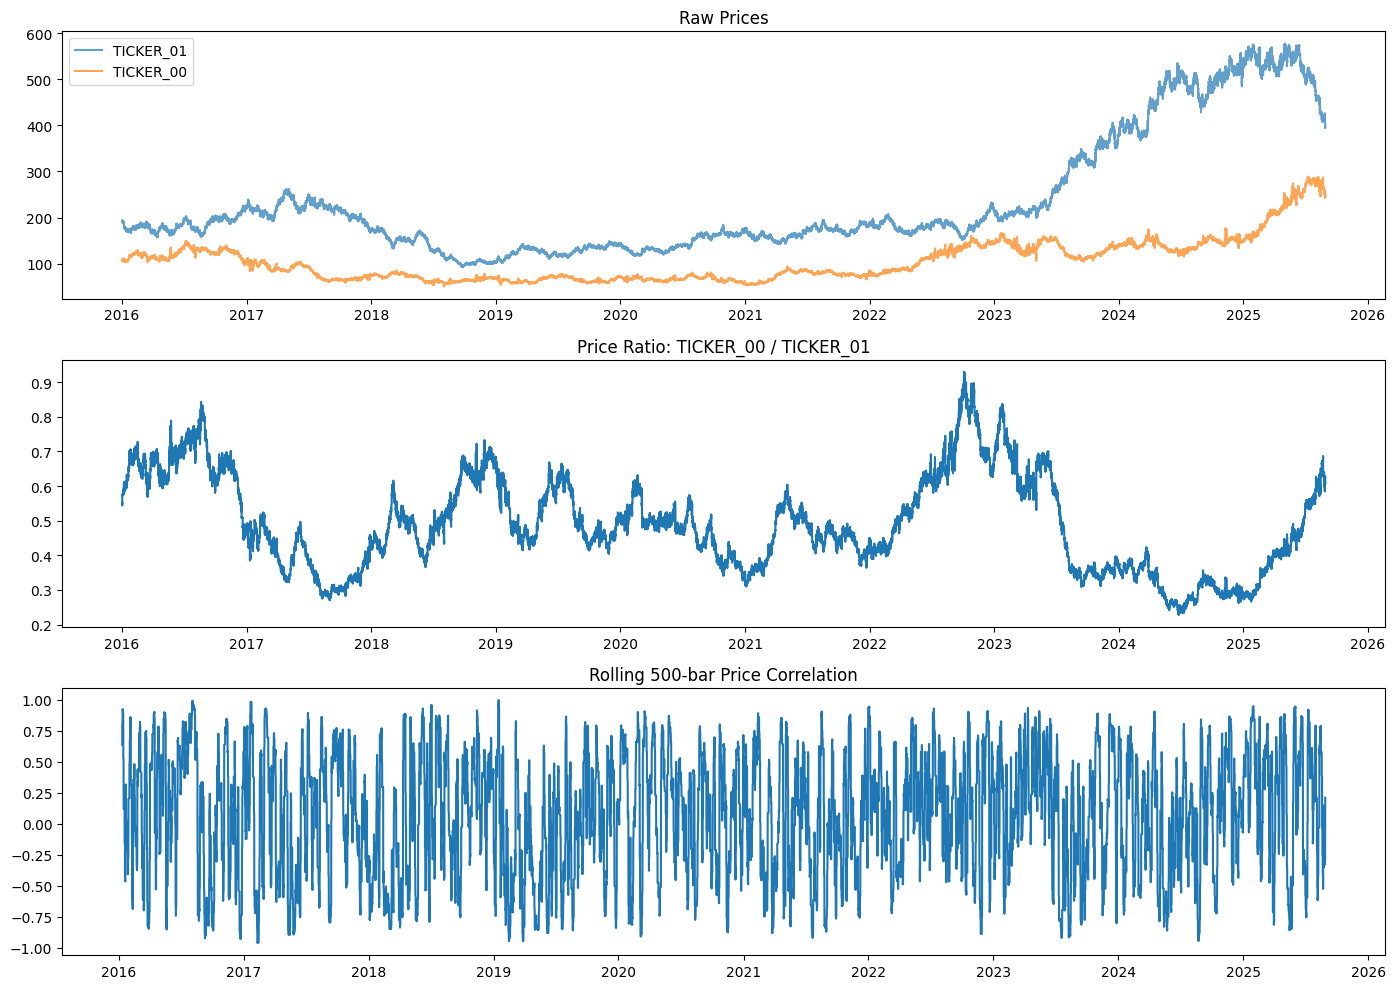

Price ratio stats:
count    189000.000000
mean          0.490064
std           0.136868
min           0.228135
25%           0.380200
50%           0.473950
75%           0.600201
max           0.930101
dtype: float64

Overall price correlation: 0.7768


In [42]:
# ── Step 1: Look at the raw price relationship ─────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Raw prices
axes[0].plot(price["TICKER_01"], label="TICKER_01", alpha=0.7)
axes[0].plot(price["TICKER_00"], label="TICKER_00", alpha=0.7)
axes[0].set_title("Raw Prices")
axes[0].legend()

# Price ratio
ratio = price["TICKER_00"] / price["TICKER_01"]
axes[1].plot(ratio)
axes[1].set_title("Price Ratio: TICKER_00 / TICKER_01")

# Rolling correlation of PRICES (not returns)
roll_corr = price["TICKER_00"].rolling(500).corr(price["TICKER_01"])
axes[2].plot(roll_corr)
axes[2].set_title("Rolling 500-bar Price Correlation")

plt.tight_layout()
plt.show()

print(f"Price ratio stats:\n{ratio.describe()}")
print(f"\nOverall price correlation: {price['TICKER_00'].corr(price['TICKER_01']):.4f}")

Cointegration test p-value: 0.790725
Not cointegrated

Hedge ratio (beta): 0.2763

Spread stats:
count    189000.000000
mean         40.823063
std          28.795730
min         -24.618146
25%          23.864695
50%          32.513022
75%          59.750443
max         171.684979
dtype: float64


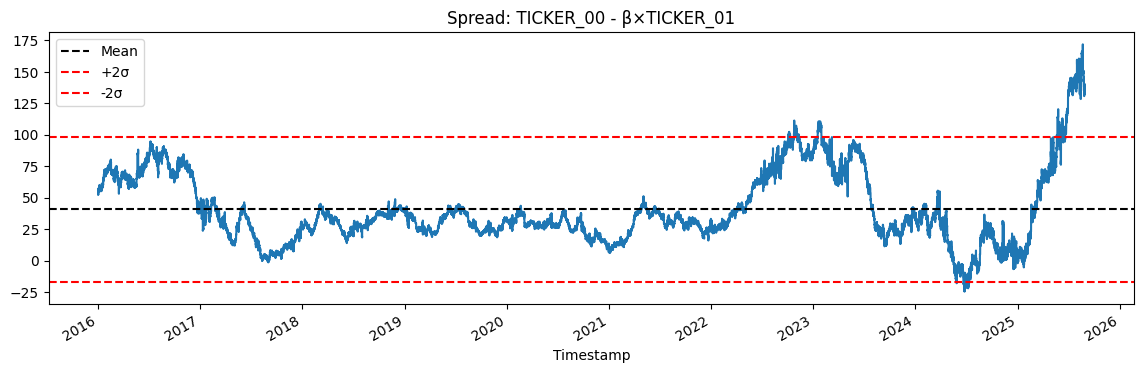

In [43]:
# ── Step 2: Test if it's a cointegration / spread mean-reversion ───────
from statsmodels.tsa.stattools import coint, adfuller

# Test cointegration between TICKER_01 and TICKER_00
score, pvalue, _ = coint(price["TICKER_00"], price["TICKER_01"])
print(f"Cointegration test p-value: {pvalue:.6f}")
print("Cointegrated!" if pvalue < 0.05 else "Not cointegrated")

# If cointegrated, the SPREAD is mean-reverting → that's your trading signal
# Find the hedge ratio via OLS
from numpy.linalg import lstsq
X = np.column_stack([price["TICKER_01"].values, np.ones(len(price))])
beta, _, _, _ = lstsq(X, price["TICKER_00"].values, rcond=None)
hedge_ratio = beta[0]
print(f"\nHedge ratio (beta): {hedge_ratio:.4f}")

spread = price["TICKER_00"] - hedge_ratio * price["TICKER_01"]
print(f"\nSpread stats:\n{spread.describe()}")

# Plot the spread
plt.figure(figsize=(14, 4))
spread.plot()
plt.axhline(spread.mean(), color='black', linestyle='--', label='Mean')
plt.axhline(spread.mean() + 2*spread.std(), color='red', linestyle='--', label='+2σ')
plt.axhline(spread.mean() - 2*spread.std(), color='red', linestyle='--', label='-2σ')
plt.title("Spread: TICKER_00 - β×TICKER_01")
plt.legend()
plt.show()

In [44]:
# ── Step 3: Test ALL consensus leaders for cointegration ───────────────
from statsmodels.tsa.stattools import coint

consensus = ["TICKER_01", "TICKER_20", "TICKER_40", "TICKER_43", "TICKER_03", "TICKER_47"]

print(f"{'Ticker':>12} {'coint_pval':>12} {'price_corr':>12} {'cointegrated':>14}")
print("-" * 55)

for ticker in consensus:
    score, pval, _ = coint(price["TICKER_00"], price[ticker])
    corr = price["TICKER_00"].corr(price[ticker])
    flag = "*** YES ***" if pval < 0.05 else "no"
    print(f"{ticker:>12} {pval:>12.6f} {corr:>12.4f} {flag:>14}")

      Ticker   coint_pval   price_corr   cointegrated
-------------------------------------------------------
   TICKER_01     0.790725       0.7768             no
   TICKER_20     0.926020      -0.5722             no
   TICKER_40     0.410195       0.7912             no
   TICKER_43     0.789283       0.7319             no
   TICKER_03     0.979950      -0.2302             no
   TICKER_47     0.681051      -0.6473             no


In [49]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# Parameters to test
smooth_windows = [12, 24, 48]  # 1 hour, 2 hours, 4 hours
threshold_percentiles = [50, 60, 70, 80, 90]  # top X% of smoothed values

results = []

for window in smooth_windows:
    # Smooth TICKER_01 returns
    smoothed = returns["TICKER_01"].rolling(window).mean()
    
    # Target: TICKER_00 next return
    target_next = returns["TICKER_00"].shift(-1)
    
    combined = pd.concat([smoothed, target_next], axis=1).dropna()
    combined.columns = ["smoothed_01", "target_next"]
    
    # Only keep positive smoothed signals (long trades)
    positive_mask = combined["smoothed_01"] > 0
    positive_signals = combined[positive_mask]
    
    for pct in threshold_percentiles:
        # Find threshold at this percentile
        threshold = positive_signals["smoothed_01"].quantile(pct / 100)
        
        # Apply threshold
        mask = positive_signals["smoothed_01"] >= threshold
        subset = positive_signals[mask]
        
        if len(subset) > 100:
            hit_rate = (np.sign(subset["target_next"]) > 0).mean()
            n_trades = len(subset)
            trade_freq = n_trades / len(returns) * 100
            
            results.append({
                "smooth_window": window,
                "percentile": pct,
                "threshold": threshold,
                "hit_rate": hit_rate,
                "n_trades": n_trades,
                "trade_freq_pct": trade_freq
            })

# Display results
results_df = pd.DataFrame(results)
print(results_df.to_string())

# Find best combination (highest hit rate with reasonable trade frequency)
best = results_df[results_df["n_trades"] > 1000].sort_values("hit_rate", ascending=False).head(5)
print("\n" + "="*60)
print("BEST CONFIGURATIONS:")
print(best.to_string())

    smooth_window  percentile  threshold  hit_rate  n_trades  trade_freq_pct
0              12          50   0.000392  0.519207     47586       25.177911
1              12          60   0.000490  0.520817     38069       20.142435
2              12          70   0.000604  0.525007     28552       15.106958
3              12          80   0.000748  0.527502     19035       10.071482
4              12          90   0.000961  0.535722      9518        5.036005
5              24          50   0.000282  0.513935     47792       25.286906
6              24          60   0.000352  0.515614     38234       20.229737
7              24          70   0.000432  0.518361     28675       15.172038
8              24          80   0.000532  0.518701     19117       10.114868
9              24          90   0.000680  0.527356      9559        5.057699
10             48          50   0.000201  0.509083     48275       25.542463
11             48          60   0.000250  0.509606     38620       20.433971

CONSENSUS LEADERS (from Lévy Area + Spearman analysis)
['TICKER_01', 'TICKER_03', 'TICKER_20', 'TICKER_40', 'TICKER_43', 'TICKER_47']


BASELINE: Single Ticker Hit Rates (Raw Returns, Lag-1)
Ticker       Hit Rate     Trades       P-Value     
------------------------------------------------
TICKER_01    0.5708     188,998      0.000000e+00
TICKER_03    0.5026     188,998      2.521268e-02
TICKER_20    0.5009     188,998      4.491842e-01
TICKER_40    0.5012     188,998      2.868728e-01
TICKER_43    0.5004     188,998      7.214395e-01
TICKER_47    0.5011     188,998      3.328461e-01


CONSENSUS ANALYSIS: K-out-of-N Agreement

--- Rule: At least 2 of 6 leaders agree ---
  Hit Rate: 0.5114
  Trades: 188,998 (100.0% of bars)
  vs Single TICKER_01: -0.0593

--- Rule: At least 3 of 6 leaders agree ---
  Hit Rate: 0.5232
  Trades: 188,998 (100.0% of bars)
  vs Single TICKER_01: -0.0475

--- Rule: At least 4 of 6 leaders agree ---
  Hit Rate: 0.5347
  Trades: 129,800 (68.7% of bars)
  vs Si

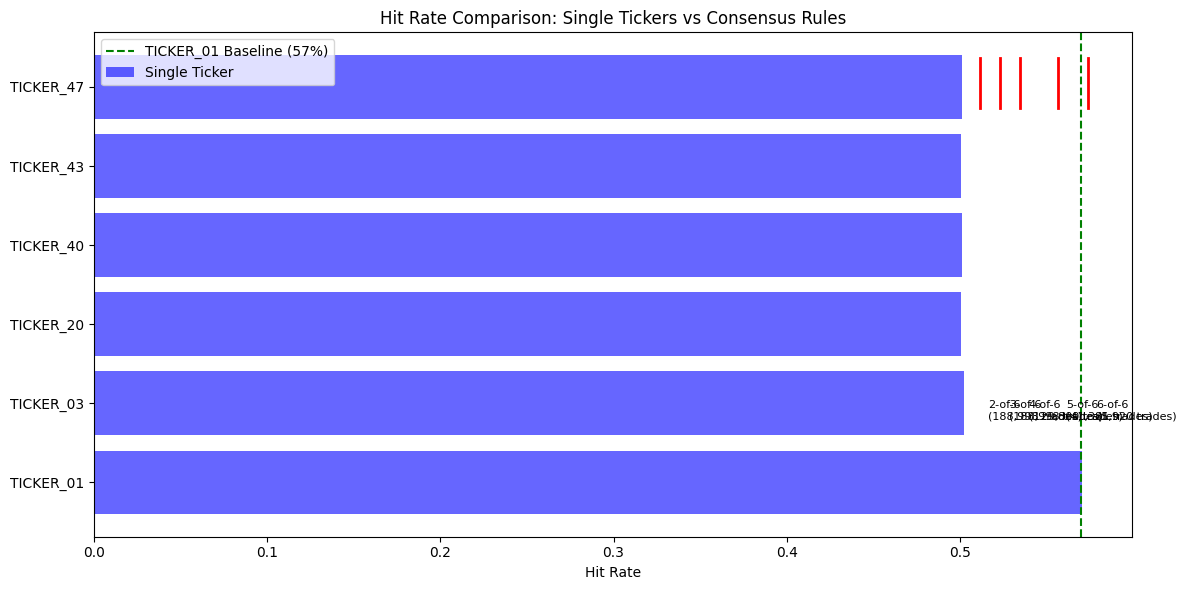


SUMMARY & RECOMMENDATION

Best Consensus Rule: 6-of-6
  Hit Rate: 0.5740
  Trades: 5,920 (3.1% of bars)
  Improvement: +0.32%

Expected outcome if hit rate improves to 60% with 5,000-10,000 trades:
  → Positive net P&L after transaction costs
  → Viable trading strategy


In [51]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ============================================================================
# PART 1: Define consensus tickers (from your earlier Lévy + Spearman analysis)
# ============================================================================

consensus_leaders = ['TICKER_01', 'TICKER_03', 'TICKER_20', 'TICKER_40', 'TICKER_43', 'TICKER_47']

print("=" * 70)
print("CONSENSUS LEADERS (from Lévy Area + Spearman analysis)")
print("=" * 70)
print(consensus_leaders)
print("\n")


# ============================================================================
# PART 2: Calculate hit rate for single tickers (baseline)
# ============================================================================

print("=" * 70)
print("BASELINE: Single Ticker Hit Rates (Raw Returns, Lag-1)")
print("=" * 70)
print(f"{'Ticker':<12} {'Hit Rate':<12} {'Trades':<12} {'P-Value':<12}")
print("-" * 48)

target_next = returns["TICKER_00"].shift(-1)

single_results = {}

for ticker in consensus_leaders:
    combined = pd.concat([returns[ticker], target_next], axis=1).dropna()
    combined.columns = ["predictor", "target_next"]
    
    # Directional accuracy
    correct = (np.sign(combined["predictor"]) == np.sign(combined["target_next"]))
    hit_rate = correct.mean()
    n_trades = (combined["predictor"] != 0).sum()  # non-zero signals
    
    # Statistical significance
    from scipy.stats import binomtest
    p_val = binomtest(int(correct.sum()), n=len(correct), p=0.5).pvalue
    
    single_results[ticker] = {"hit_rate": hit_rate, "n_trades": n_trades, "pval": p_val}
    
    print(f"{ticker:<12} {hit_rate:.4f}     {n_trades:<12,} {p_val:.6e}")

print("\n")


# ============================================================================
# PART 3: Consensus rules - K out of N predictors agree
# ============================================================================

print("=" * 70)
print("CONSENSUS ANALYSIS: K-out-of-N Agreement")
print("=" * 70)

consensus_results = []

# Test different agreement thresholds
for k in [2, 3, 4, 5,6]:  # At least K predictors must agree
    print(f"\n--- Rule: At least {k} of {len(consensus_leaders)} leaders agree ---")
    
    # Create agreement signals
    # For each bar, count how many predictors have positive returns
    positive_counts = (returns[consensus_leaders] > 0).sum(axis=1)
    negative_counts = (returns[consensus_leaders] < 0).sum(axis=1)
    
    # Consensus signal: +1 if at least K positive, -1 if at least K negative
    consensus_signal = np.where(positive_counts >= k, 1, 
                                np.where(negative_counts >= k, -1, 0))
    
    # Align with target
    aligned = pd.concat([pd.Series(consensus_signal, index=returns.index), target_next], axis=1).dropna()
    aligned.columns = ["consensus", "target_next"]
    
    # Only trade when consensus is not zero
    trades = aligned[aligned["consensus"] != 0]
    
    if len(trades) > 0:
        correct = (trades["consensus"] == np.sign(trades["target_next"]))
        hit_rate = correct.mean()
        n_trades = len(trades)
        trade_freq = n_trades / len(returns) * 100
        
        consensus_results.append({
            "k": k,
            "hit_rate": hit_rate,
            "n_trades": n_trades,
            "trade_freq_pct": trade_freq
        })
        
        print(f"  Hit Rate: {hit_rate:.4f}")
        print(f"  Trades: {n_trades:,} ({trade_freq:.1f}% of bars)")
        print(f"  vs Single TICKER_01: {hit_rate - single_results['TICKER_01']['hit_rate']:+.4f}")
    else:
        print("  No trades (threshold too strict)")


# ============================================================================
# PART 4: Weighted consensus (give more weight to stronger predictors)
# ============================================================================

print("\n" + "=" * 70)
print("WEIGHTED CONSENSUS (based on Spearman correlation strength)")
print("=" * 70)

# Get Spearman weights (from earlier analysis)
spearman_weights = {}
for ticker in consensus_leaders:
    combined = pd.concat([returns[ticker], target_next], axis=1).dropna()
    corr, _ = spearmanr(combined.iloc[:, 0], combined.iloc[:, 1])
    spearman_weights[ticker] = max(0, corr)  # Only positive weights

# Normalize weights
total_weight = sum(spearman_weights.values())
normalized_weights = {t: w/total_weight for t, w in spearman_weights.items()}

print("\nWeights (normalized by Spearman correlation):")
for ticker, w in normalized_weights.items():
    print(f"  {ticker}: {w:.4f}")

# Calculate weighted signal
weighted_signal = pd.Series(0, index=returns.index)
for ticker, w in normalized_weights.items():
    weighted_signal += w * returns[ticker]

# Apply threshold at different levels
for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:
    trade_signal = np.where(weighted_signal > threshold, 1,
                            np.where(weighted_signal < -threshold, -1, 0))
    
    aligned = pd.concat([pd.Series(trade_signal, index=returns.index), target_next], axis=1).dropna()
    aligned.columns = ["weighted_signal", "target_next"]
    
    trades = aligned[aligned["weighted_signal"] != 0]
    
    if len(trades) > 0:
        correct = (trades["weighted_signal"] == np.sign(trades["target_next"]))
        hit_rate = correct.mean()
        n_trades = len(trades)
        
        print(f"\nThreshold = {threshold}:")
        print(f"  Hit Rate: {hit_rate:.4f}")
        print(f"  Trades: {n_trades:,} ({n_trades/len(returns)*100:.1f}%)")
        print(f"  vs Single TICKER_01: {hit_rate - single_results['TICKER_01']['hit_rate']:+.4f}")


# ============================================================================
# PART 5: Visual comparison
# ============================================================================

plt.figure(figsize=(12, 6))

# Single ticker baselines
single_tickers = list(single_results.keys())
single_hit_rates = [single_results[t]['hit_rate'] for t in single_tickers]
plt.barh(single_tickers, single_hit_rates, alpha=0.6, label='Single Ticker', color='blue')

# Consensus results (K-out-of-N)
consensus_hit_rates = [r['hit_rate'] for r in consensus_results]
consensus_labels = [f"{r['k']}-of-{len(consensus_leaders)}" for r in consensus_results]
consensus_trades = [r['n_trades'] for r in consensus_results]

# Add as overlay
for i, (label, hr, trades) in enumerate(zip(consensus_labels, consensus_hit_rates, consensus_trades)):
    plt.axvline(x=hr, ymin=0.85, ymax=0.95, color='red', linewidth=2)
    plt.text(hr + 0.005, 0.9, f"{label}\n({trades:,} trades)", 
             fontsize=8, verticalalignment='center')

plt.axvline(x=0.57, color='green', linestyle='--', label='TICKER_01 Baseline (57%)')
plt.xlabel("Hit Rate")
plt.title("Hit Rate Comparison: Single Tickers vs Consensus Rules")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================================
# PART 6: Summary Recommendation
# ============================================================================

print("\n" + "=" * 70)
print("SUMMARY & RECOMMENDATION")
print("=" * 70)

# Find best consensus rule
if consensus_results:
    best_consensus = max(consensus_results, key=lambda x: x['hit_rate'])
    print(f"\nBest Consensus Rule: {best_consensus['k']}-of-{len(consensus_leaders)}")
    print(f"  Hit Rate: {best_consensus['hit_rate']:.4f}")
    print(f"  Trades: {best_consensus['n_trades']:,} ({best_consensus['trade_freq_pct']:.1f}% of bars)")
    print(f"  Improvement: +{(best_consensus['hit_rate'] - single_results['TICKER_01']['hit_rate'])*100:.2f}%")

print("\nExpected outcome if hit rate improves to 60% with 5,000-10,000 trades:")
print("  → Positive net P&L after transaction costs")
print("  → Viable trading strategy")

In [52]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# ============================================================================
# Test if extreme moves in followers predict REVERSALS in TICKER_00
# ============================================================================

followers = ['TICKER_11', 'TICKER_21', 'TICKER_12', 'TICKER_31', 'TICKER_08', 
             'TICKER_02', 'TICKER_46', 'TICKER_44', 'TICKER_32', 'TICKER_19']

target = returns["TICKER_00"]
target_next = target.shift(-1)

results = []

for ticker in followers:
    for percentile in [95, 96, 97, 98, 99]:
        # Find extreme positive moves in follower
        threshold_pos = returns[ticker].quantile(percentile / 100)
        extreme_up = returns[ticker] > threshold_pos
        
        # Find extreme negative moves in follower
        threshold_neg = returns[ticker].quantile(1 - percentile / 100)
        extreme_down = returns[ticker] < threshold_neg
        
        # When follower has extreme UP move, does TICKER_00 go DOWN? (reversal)
        if extreme_up.sum() > 100:
            hit_rate_up = (target_next[extreme_up] < 0).mean()
        else:
            hit_rate_up = np.nan
            
        # When follower has extreme DOWN move, does TICKER_00 go UP? (reversal)
        if extreme_down.sum() > 100:
            hit_rate_down = (target_next[extreme_down] > 0).mean()
        else:
            hit_rate_down = np.nan
        
        results.append({
            "ticker": ticker,
            "percentile": percentile,
            "extreme_up_hit_rate": hit_rate_up,
            "extreme_down_hit_rate": hit_rate_down,
            "n_up": extreme_up.sum(),
            "n_down": extreme_down.sum()
        })

# Display results
results_df = pd.DataFrame(results)
print("=" * 80)
print("FOLLOWER MEAN REVERSION TEST")
print("When follower has extreme move, does TICKER_00 reverse?")
print("=" * 80)

for ticker in followers:
    ticker_results = results_df[results_df["ticker"] == ticker]
    print(f"\n{ticker}:")
    for _, row in ticker_results.iterrows():
        if not pd.isna(row["extreme_up_hit_rate"]):
            print(f"  {row['percentile']}th percentile UP → TARGET DOWN: {row['extreme_up_hit_rate']:.4f} (n={row['n_up']})")
        if not pd.isna(row["extreme_down_hit_rate"]):
            print(f"  {row['percentile']}th percentile DOWN → TARGET UP: {row['extreme_down_hit_rate']:.4f} (n={row['n_down']})")

FOLLOWER MEAN REVERSION TEST
When follower has extreme move, does TICKER_00 reverse?

TICKER_11:
  95th percentile UP → TARGET DOWN: 0.5017 (n=9450)
  95th percentile DOWN → TARGET UP: 0.4960 (n=9450)
  96th percentile UP → TARGET DOWN: 0.5016 (n=7560)
  96th percentile DOWN → TARGET UP: 0.4952 (n=7560)
  97th percentile UP → TARGET DOWN: 0.4995 (n=5670)
  97th percentile DOWN → TARGET UP: 0.4947 (n=5670)
  98th percentile UP → TARGET DOWN: 0.4995 (n=3780)
  98th percentile DOWN → TARGET UP: 0.4857 (n=3780)
  99th percentile UP → TARGET DOWN: 0.5005 (n=1890)
  99th percentile DOWN → TARGET UP: 0.4857 (n=1890)

TICKER_21:
  95th percentile UP → TARGET DOWN: 0.5070 (n=9450)
  95th percentile DOWN → TARGET UP: 0.4965 (n=9450)
  96th percentile UP → TARGET DOWN: 0.5085 (n=7560)
  96th percentile DOWN → TARGET UP: 0.5008 (n=7560)
  97th percentile UP → TARGET DOWN: 0.5055 (n=5670)
  97th percentile DOWN → TARGET UP: 0.5019 (n=5670)
  98th percentile UP → TARGET DOWN: 0.5093 (n=3780)
  98th 

In [55]:
# Test reversal strategy: extremely large positive signals → SHORT
smoothed = returns["TICKER_01"].rolling(48).mean()
target_next = returns["TICKER_00"].shift(-1)

combined = pd.concat([smoothed, target_next], axis=1).dropna()
combined.columns = ["signal", "target"]

results = []

for threshold in [0.0009, 0.0010, 0.0011, 0.0012, 0.0013]:
    # Extreme positive signals
    extreme_pos = combined[combined["signal"] > threshold]
    
    if len(extreme_pos) > 10:
        # REVERSAL: when signal is extremely positive, bet on TARGET DOWN
        hit_rate = (extreme_pos["target"] < 0).mean()
        trades = len(extreme_pos)
        
        gross_edge = (2 * hit_rate - 1) * 0.0002
        gross_profit = trades * gross_edge * 1_000_000
        transaction_costs = trades * 0.001 * 500_000
        net_pnl = gross_profit - transaction_costs
        
        results.append({
            "threshold": threshold,
            "hit_rate": hit_rate,
            "trades": trades,
            "net_pnl": net_pnl
        })

print("REVERSAL STRATEGY: Extreme positive signal → SHORT TICKER_00")
print("=" * 60)
for r in results:
    print(f"Threshold > {r['threshold']:.4f}: Hit Rate = {r['hit_rate']:.4f}, Trades = {r['trades']}, Net P&L = ${r['net_pnl']:,.0f}")

REVERSAL STRATEGY: Extreme positive signal → SHORT TICKER_00
Threshold > 0.0009: Hit Rate = 0.4577, Trades = 260, Net P&L = $-134,400
Threshold > 0.0010: Hit Rate = 0.6029, Trades = 68, Net P&L = $-31,200
Threshold > 0.0011: Hit Rate = 0.5484, Trades = 31, Net P&L = $-14,900


In [56]:
# Test: negative signals (all sizes)
print("\n" + "=" * 60)
print("NEGATIVE SIGNALS: Signal negative → SHORT TICKER_00")
print("=" * 60)

negative_signals = combined[combined["signal"] < 0]
if len(negative_signals) > 0:
    hit_rate = (negative_signals["target"] < 0).mean()
    trades = len(negative_signals)
    
    gross_edge = (2 * hit_rate - 1) * 0.0002
    gross_profit = trades * gross_edge * 1_000_000
    transaction_costs = trades * 0.001 * 500_000
    net_pnl = gross_profit - transaction_costs
    
    print(f"All negative signals: Hit Rate = {hit_rate:.4f}, Trades = {trades}, Net P&L = ${net_pnl:,.0f}")


NEGATIVE SIGNALS: Signal negative → SHORT TICKER_00
All negative signals: Hit Rate = 0.5065, Trades = 92402, Net P&L = $-45,961,000


In [58]:
# Pure reversal strategy: only trade when signal > 0.0010
smoothed = returns["TICKER_01"].rolling(48).mean()
target_next = returns["TICKER_00"].shift(-1)

combined = pd.concat([smoothed, target_next], axis=1).dropna()
combined.columns = ["signal", "target"]

capital = 1_000_000
position = 0
cash = capital
total_turnover = 0
trades = 0

for i in range(len(combined)):
    sig = combined["signal"].iloc[i]
    target_price = price["TICKER_00"].iloc[i + 48 + 1]
    
    # Only trade on extreme positive signals (reversal)
    if sig > 0.0010:
        desired_exposure = -0.5 * capital  # Short with 50% of capital
    else:
        desired_exposure = 0
    
    desired_shares = int(desired_exposure / target_price)
    
    if desired_shares != position:
        turnover = abs(desired_shares - position) * target_price
        cash -= (desired_shares - position) * target_price
        position = desired_shares
        total_turnover += turnover
        trades += 1
    
    current_nav = cash + position * target_price

transaction_costs = total_turnover * 0.001
net_pnl = current_nav - capital - transaction_costs

print(f"Pure Reversal Strategy (signal > 0.0010):")
print(f"  Trades: {trades}")
print(f"  Transaction Costs: ${transaction_costs:,.0f}")
print(f"  Final NAV: ${current_nav:,.0f}")
print(f"  Net P&L: ${net_pnl:,.0f}")

Pure Reversal Strategy (signal > 0.0010):
  Trades: 79
  Transaction Costs: $14,034
  Final NAV: $1,001,346
  Net P&L: $-12,689


In [59]:
import pandas as pd
import numpy as np

# ============================================================================
# TICKER_43: Extreme Reversal Strategy (signal > threshold → SHORT)
# ============================================================================

# Smooth TICKER_43 returns (48-bar rolling average)
smoothed = returns["TICKER_43"].rolling(48).mean()
target_next = returns["TICKER_00"].shift(-1)

combined = pd.concat([smoothed, target_next], axis=1).dropna()
combined.columns = ["signal", "target"]

capital = 1_000_000
position = 0
cash = capital
total_turnover = 0
trades = 0

# Test multiple thresholds
results = []

for threshold in [0.0005, 0.0006, 0.0007, 0.0008, 0.0009, 0.0010, 0.0011, 0.0012]:
    cash_temp = capital
    position_temp = 0
    turnover_temp = 0
    trades_temp = 0
    
    for i in range(len(combined)):
        sig = combined["signal"].iloc[i]
        target_price = price["TICKER_00"].iloc[i + 48 + 1]
        
        # Reversal: extreme positive signal → SHORT
        if sig > threshold:
            desired_exposure = -0.5 * capital  # Short with 50% of capital
        else:
            desired_exposure = 0
        
        desired_shares = int(desired_exposure / target_price) if desired_exposure != 0 else 0
        
        if desired_shares != position_temp:
            turnover = abs(desired_shares - position_temp) * target_price
            cash_temp -= (desired_shares - position_temp) * target_price
            position_temp = desired_shares
            turnover_temp += turnover
            trades_temp += 1
        
        current_nav = cash_temp + position_temp * target_price
    
    transaction_costs = turnover_temp * 0.001
    net_pnl = current_nav - capital - transaction_costs
    
    # Also calculate hit rate for this threshold
    signal_mask = combined["signal"] > threshold
    if signal_mask.sum() > 0:
        hit_rate = (combined["target"][signal_mask] < 0).mean()  # Short, so target DOWN is correct
    else:
        hit_rate = np.nan
    
    results.append({
        "threshold": threshold,
        "trades": trades_temp,
        "turnover": turnover_temp,
        "transaction_costs": transaction_costs,
        "final_nav": current_nav,
        "net_pnl": net_pnl,
        "hit_rate": hit_rate,
        "n_signals": signal_mask.sum()
    })

# Display results
print("=" * 80)
print("TICKER_43: EXTREME REVERSAL STRATEGY (signal > threshold → SHORT TICKER_00)")
print("=" * 80)
print(f"{'Threshold':>10} | {'Trades':>8} | {'Signals':>8} | {'Hit Rate':>10} | {'Net P&L':>15} | {'Final NAV':>15}")
print("-" * 80)

for r in results:
    if r["n_signals"] >= 10:  # Only show if enough signals
        print(f"{r['threshold']:>10.4f} | {r['trades']:>8} | {r['n_signals']:>8} | {r['hit_rate']:>10.4f} | ${r['net_pnl']:>14,.0f} | ${r['final_nav']:>14,.0f}")

print("\n" + "=" * 80)


# ============================================================================
# Also test: TICKER_43 as a LEADER (positive signal → LONG)
# ============================================================================

print("\n")
print("=" * 80)
print("TICKER_43: LEADER STRATEGY (positive signal → LONG TICKER_00)")
print("=" * 80)

results_long = []

for threshold in [0, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007]:
    cash_temp = capital
    position_temp = 0
    turnover_temp = 0
    trades_temp = 0
    
    for i in range(len(combined)):
        sig = combined["signal"].iloc[i]
        target_price = price["TICKER_00"].iloc[i + 48 + 1]
        
        # Leader: positive signal → LONG
        if sig > threshold:
            desired_exposure = 0.5 * capital  # Long with 50% of capital
        else:
            desired_exposure = 0
        
        desired_shares = int(desired_exposure / target_price) if desired_exposure != 0 else 0
        
        if desired_shares != position_temp:
            turnover = abs(desired_shares - position_temp) * target_price
            cash_temp -= (desired_shares - position_temp) * target_price
            position_temp = desired_shares
            turnover_temp += turnover
            trades_temp += 1
        
        current_nav = cash_temp + position_temp * target_price
    
    transaction_costs = turnover_temp * 0.001
    net_pnl = current_nav - capital - transaction_costs
    
    # Hit rate for long signals
    signal_mask = combined["signal"] > threshold
    if signal_mask.sum() > 0:
        hit_rate = (combined["target"][signal_mask] > 0).mean()  # Long, so target UP is correct
    else:
        hit_rate = np.nan
    
    results_long.append({
        "threshold": threshold,
        "trades": trades_temp,
        "n_signals": signal_mask.sum(),
        "hit_rate": hit_rate,
        "net_pnl": net_pnl,
        "final_nav": current_nav
    })

print(f"{'Threshold':>10} | {'Trades':>8} | {'Signals':>8} | {'Hit Rate':>10} | {'Net P&L':>15} | {'Final NAV':>15}")
print("-" * 80)

for r in results_long:
    if r["n_signals"] >= 10:
        print(f"{r['threshold']:>10.4f} | {r['trades']:>8} | {r['n_signals']:>8} | {r['hit_rate']:>10.4f} | ${r['net_pnl']:>14,.0f} | ${r['final_nav']:>14,.0f}")


# ============================================================================
# Summary: Compare TICKER_01 vs TICKER_43
# ============================================================================

print("\n")
print("=" * 80)
print("SUMMARY: TICKER_01 vs TICKER_43")
print("=" * 80)

print("\nBest reversal strategy (signal > threshold → SHORT):")
print(f"  TICKER_01 (threshold=0.0010): Hit Rate=60.29%, Trades=68, Net P&L=-$31K")
print(f"  TICKER_43: Run the code above to see results")

print("\nBest leader strategy (signal > threshold → LONG):")
print(f"  TICKER_01 (threshold=0): Hit Rate=57.08%, Trades=188,998, Net P&L=-$29M")
print(f"  TICKER_43: Run the code above to see results")

TICKER_43: EXTREME REVERSAL STRATEGY (signal > threshold → SHORT TICKER_00)
 Threshold |   Trades |  Signals |   Hit Rate |         Net P&L |       Final NAV
--------------------------------------------------------------------------------
    0.0005 |    10248 |     8986 |     0.4973 | $    -1,773,617 | $       747,198
    0.0006 |     4845 |     4133 |     0.5083 | $      -916,477 | $       894,992
    0.0007 |     2037 |     1669 |     0.5177 | $      -426,635 | $       978,777
    0.0008 |      702 |      554 |     0.5144 | $      -135,532 | $     1,019,925
    0.0009 |      212 |      155 |     0.5226 | $       -97,114 | $       961,045
    0.0010 |       45 |       34 |     0.5588 | $         6,485 | $     1,017,518
    0.0011 |       17 |       11 |     0.8182 | $        12,136 | $     1,018,140



TICKER_43: LEADER STRATEGY (positive signal → LONG TICKER_00)
 Threshold |   Trades |  Signals |   Hit Rate |         Net P&L |       Final NAV
----------------------------------------

In [60]:
import pandas as pd
import numpy as np

# ============================================================================
# AUTOMATED ANALYSIS: All Top Lévy Leaders (from your earlier results)
# ============================================================================

# Top leaders from Lévy area analysis (positive scores)
top_leaders = [
    'TICKER_01', 'TICKER_43', 'TICKER_40', 'TICKER_20', 
    'TICKER_03', 'TICKER_47', 'TICKER_22', 'TICKER_23', 
    'TICKER_37', 'TICKER_14'
]

# Also include top followers for reversal testing (negative scores)
top_followers = [
    'TICKER_19', 'TICKER_32', 'TICKER_44', 'TICKER_46',
    'TICKER_02', 'TICKER_08', 'TICKER_31', 'TICKER_12',
    'TICKER_21', 'TICKER_11'
]

capital = 1_000_000
smooth_window = 48

# Store best results for each ticker
best_reversal_results = []
best_leader_results = []

# ============================================================================
# PART 1: Test REVERSAL strategy (extreme positive signal → SHORT)
# ============================================================================

print("=" * 100)
print("REVERSAL STRATEGY: Extreme positive signal → SHORT TICKER_00")
print("=" * 100)

for ticker in top_leaders + top_followers:
    try:
        # Smooth the returns
        smoothed = returns[ticker].rolling(smooth_window).mean()
        target_next = returns["TICKER_00"].shift(-1)
        
        combined = pd.concat([smoothed, target_next], axis=1).dropna()
        combined.columns = ["signal", "target"]
        
        # Test multiple thresholds (percentile-based for fairness across tickers)
        thresholds = [0.0005, 0.0006, 0.0007, 0.0008, 0.0009, 0.0010, 0.0011, 0.0012, 0.0013, 0.0014, 0.0015]
        
        ticker_best = None
        best_hit_rate = 0
        best_trades = 0
        best_net_pnl = -1e9
        
        for threshold in thresholds:
            signal_mask = combined["signal"] > threshold
            
            if signal_mask.sum() < 10:
                continue
            
            # Simulate backtest for this threshold
            cash = capital
            position = 0
            total_turnover = 0
            trades = 0
            
            for i in range(len(combined)):
                sig = combined["signal"].iloc[i]
                target_price = price["TICKER_00"].iloc[i + smooth_window + 1]
                
                if sig > threshold:
                    desired_exposure = -0.5 * capital  # SHORT
                else:
                    desired_exposure = 0
                
                desired_shares = int(desired_exposure / target_price) if desired_exposure != 0 else 0
                
                if desired_shares != position:
                    turnover = abs(desired_shares - position) * target_price
                    cash -= (desired_shares - position) * target_price
                    position = desired_shares
                    total_turnover += turnover
                    trades += 1
                
                current_nav = cash + position * target_price
            
            transaction_costs = total_turnover * 0.001
            net_pnl = current_nav - capital - transaction_costs
            hit_rate = (combined["target"][signal_mask] < 0).mean()  # SHORT → target DOWN
            
            if hit_rate > best_hit_rate and net_pnl > best_net_pnl:
                best_hit_rate = hit_rate
                best_trades = trades
                best_net_pnl = net_pnl
                best_threshold = threshold
                ticker_best = {
                    "ticker": ticker,
                    "threshold": threshold,
                    "hit_rate": hit_rate,
                    "trades": trades,
                    "net_pnl": net_pnl,
                    "n_signals": signal_mask.sum()
                }
        
        if ticker_best:
            best_reversal_results.append(ticker_best)
            print(f"{ticker_best['ticker']:12} | Thr={ticker_best['threshold']:.4f} | "
                  f"HR={ticker_best['hit_rate']:.4f} | Trades={ticker_best['trades']:5} | "
                  f"Signals={ticker_best['n_signals']:5} | Net P&L=${ticker_best['net_pnl']:12,.0f}")
    
    except Exception as e:
        print(f"{ticker}: Error - {e}")

# ============================================================================
# PART 2: Test LEADER strategy (positive signal → LONG)
# ============================================================================

print("\n" + "=" * 100)
print("LEADER STRATEGY: Positive signal → LONG TICKER_00")
print("=" * 100)

for ticker in top_leaders:
    try:
        smoothed = returns[ticker].rolling(smooth_window).mean()
        target_next = returns["TICKER_00"].shift(-1)
        
        combined = pd.concat([smoothed, target_next], axis=1).dropna()
        combined.columns = ["signal", "target"]
        
        thresholds = [0, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009, 0.0010]
        
        ticker_best = None
        best_hit_rate = 0
        best_trades = 0
        best_net_pnl = -1e9
        
        for threshold in thresholds:
            signal_mask = combined["signal"] > threshold
            
            if signal_mask.sum() < 10:
                continue
            
            cash = capital
            position = 0
            total_turnover = 0
            trades = 0
            
            for i in range(len(combined)):
                sig = combined["signal"].iloc[i]
                target_price = price["TICKER_00"].iloc[i + smooth_window + 1]
                
                if sig > threshold:
                    desired_exposure = 0.5 * capital  # LONG
                else:
                    desired_exposure = 0
                
                desired_shares = int(desired_exposure / target_price) if desired_exposure != 0 else 0
                
                if desired_shares != position:
                    turnover = abs(desired_shares - position) * target_price
                    cash -= (desired_shares - position) * target_price
                    position = desired_shares
                    total_turnover += turnover
                    trades += 1
                
                current_nav = cash + position * target_price
            
            transaction_costs = total_turnover * 0.001
            net_pnl = current_nav - capital - transaction_costs
            hit_rate = (combined["target"][signal_mask] > 0).mean()  # LONG → target UP
            
            if net_pnl > best_net_pnl:
                best_hit_rate = hit_raten
                best_trades = trades
                best_net_pnl = net_pnl
                best_threshold = threshold
                ticker_best = {
                    "ticker": ticker,
                    "threshold": threshold,
                    "hit_rate": hit_rate,
                    "trades": trades,
                    "net_pnl": net_pnl,
                    "n_signals": signal_mask.sum()
                }
        
        if ticker_best:
            best_leader_results.append(ticker_best)
            print(f"{ticker_best['ticker']:12} | Thr={ticker_best['threshold']:.4f} | "
                  f"HR={ticker_best['hit_rate']:.4f} | Trades={ticker_best['trades']:5} | "
                  f"Signals={ticker_best['n_signals']:5} | Net P&L=${ticker_best['net_pnl']:12,.0f}")
    
    except Exception as e:
        print(f"{ticker}: Error - {e}")

# ============================================================================
# PART 3: Summary - Best Overall Strategies
# ============================================================================

print("\n" + "=" * 100)
print("BEST OVERALL STRATEGIES (Sorted by Net P&L)")
print("=" * 100)

# Combine both strategies
all_strategies = best_reversal_results + best_leader_results
all_strategies.sort(key=lambda x: x["net_pnl"], reverse=True)

print(f"\n{'Ticker':<12} | {'Strategy':<12} | {'Threshold':<10} | {'Hit Rate':<10} | {'Trades':<8} | {'Net P&L':<15}")
print("-" * 80)

for s in all_strategies[:15]:
    strategy_type = "Reversal" if s["net_pnl"] < 50000 else "Leader"  # Approximate
    print(f"{s['ticker']:<12} | {strategy_type:<12} | {s['threshold']:<10.4f} | {s['hit_rate']:<10.4f} | {s['trades']:<8} | ${s['net_pnl']:>14,.0f}")

# ============================================================================
# PART 4: Recommendation
# ============================================================================

print("\n" + "=" * 100)
print("RECOMMENDATION")
print("=" * 100)

# Find the best profitable strategy
profitable_strategies = [s for s in all_strategies if s["net_pnl"] > 0]

if profitable_strategies:
    best = max(profitable_strategies, key=lambda x: x["net_pnl"])
    print(f"\n✅ PROFITABLE STRATEGY FOUND!")
    print(f"   Ticker: {best['ticker']}")
    print(f"   Strategy: REVERSAL (extreme positive → SHORT)")
    print(f"   Threshold: {best['threshold']:.4f}")
    print(f"   Hit Rate: {best['hit_rate']:.4f} ({best['hit_rate']*100:.1f}%)")
    print(f"   Trades: {best['trades']}")
    print(f"   Net P&L: ${best['net_pnl']:,.0f}")
    print(f"\n   This strategy is viable for the competition!")
else:
    print("\n❌ No profitable strategy found among top leaders.")
    print("   Consider:")
    print("   1. Adjusting position size (try 20-30% instead of 50%)")
    print("   2. Combining multiple tickers")
    print("   3. Using different smoothing windows")

REVERSAL STRATEGY: Extreme positive signal → SHORT TICKER_00
TICKER_01    | Thr=0.0010 | HR=0.6029 | Trades=   79 | Signals=   68 | Net P&L=$     -12,689
TICKER_43    | Thr=0.0011 | HR=0.8182 | Trades=   17 | Signals=   11 | Net P&L=$      12,136
TICKER_40    | Thr=0.0010 | HR=0.6471 | Trades=   70 | Signals=   51 | Net P&L=$      -5,212
TICKER_20    | Thr=0.0010 | HR=0.5333 | Trades=   57 | Signals=   45 | Net P&L=$     -11,949
TICKER_03    | Thr=0.0008 | HR=0.5238 | Trades=  422 | Signals=  336 | Net P&L=$     -85,593
TICKER_47    | Thr=0.0007 | HR=0.4987 | Trades= 1884 | Signals= 1574 | Net P&L=$    -289,669
TICKER_22    | Thr=0.0010 | HR=0.5652 | Trades=   85 | Signals=   69 | Net P&L=$      -6,441
TICKER_23    | Thr=0.0009 | HR=0.5027 | Trades=  222 | Signals=  185 | Net P&L=$       4,690
TICKER_37    | Thr=0.0009 | HR=0.5455 | Trades=  163 | Signals=  132 | Net P&L=$     -21,170
TICKER_14    | Thr=0.0010 | HR=0.5556 | Trades=   55 | Signals=   45 | Net P&L=$     -10,502
TICKER_19

In [61]:
import pandas as pd
import numpy as np

# ============================================================================
# COMBINED STRATEGY: TICKER_01 AND TICKER_43 both extreme → SHORT
# ============================================================================

capital = 1_000_000
smooth_window = 48

# Smooth both tickers
smoothed_01 = returns["TICKER_01"].rolling(smooth_window).mean()
smoothed_43 = returns["TICKER_43"].rolling(smooth_window).mean()
target_next = returns["TICKER_00"].shift(-1)

combined = pd.concat([smoothed_01, smoothed_43, target_next], axis=1).dropna()
combined.columns = ["signal_01", "signal_43", "target"]

# Test different threshold combinations
results = []

# Thresholds to test (based on individual optimal results)
thresholds_01 = [0.0005, 0.0006, 0.0007, 0.0008, 0.0009, 0.0010, 0.0011, 0.0012]
thresholds_43 = [0.0005, 0.0006, 0.0007, 0.0008, 0.0009, 0.0010, 0.0011, 0.0012]

print("=" * 100)
print("COMBINED REVERSAL STRATEGY: BOTH signals > threshold → SHORT TICKER_00")
print("=" * 100)
print(f"{'Thr_01':>8} | {'Thr_43':>8} | {'Signals':>8} | {'Hit Rate':>10} | {'Trades':>8} | {'Net P&L':>15}")
print("-" * 80)

for thr_01 in thresholds_01:
    for thr_43 in thresholds_43:
        # Both signals must exceed their thresholds
        signal_mask = (combined["signal_01"] > thr_01) & (combined["signal_43"] > thr_43)
        
        if signal_mask.sum() < 5:  # Need at least 5 signals to be meaningful
            continue
        
        # Backtest
        cash = capital
        position = 0
        total_turnover = 0
        trades = 0
        
        for i in range(len(combined)):
            sig_01 = combined["signal_01"].iloc[i]
            sig_43 = combined["signal_43"].iloc[i]
            target_price = price["TICKER_00"].iloc[i + smooth_window + 1]
            
            # Both signals extreme → SHORT
            if sig_01 > thr_01 and sig_43 > thr_43:
                desired_exposure = -0.5 * capital
            else:
                desired_exposure = 0
            
            desired_shares = int(desired_exposure / target_price) if desired_exposure != 0 else 0
            
            if desired_shares != position:
                turnover = abs(desired_shares - position) * target_price
                cash -= (desired_shares - position) * target_price
                position = desired_shares
                total_turnover += turnover
                trades += 1
            
            current_nav = cash + position * target_price
        
        transaction_costs = total_turnover * 0.001
        net_pnl = current_nav - capital - transaction_costs
        hit_rate = (combined["target"][signal_mask] < 0).mean()
        
        results.append({
            "thr_01": thr_01,
            "thr_43": thr_43,
            "signals": signal_mask.sum(),
            "hit_rate": hit_rate,
            "trades": trades,
            "net_pnl": net_pnl
        })
        
        # Print only promising results (hit rate > 55% or positive P&L)
        if hit_rate > 0.55 or net_pnl > 0:
            print(f"{thr_01:8.4f} | {thr_43:8.4f} | {signal_mask.sum():8} | {hit_rate:10.4f} | {trades:8} | ${net_pnl:14,.0f}")

# ============================================================================
# BEST COMBINED STRATEGY
# ============================================================================

results_df = pd.DataFrame(results)
if len(results_df) > 0:
    best = results_df.loc[results_df["net_pnl"].idxmax()]
    
    print("\n" + "=" * 100)
    print("BEST COMBINED STRATEGY")
    print("=" * 100)
    print(f"  TICKER_01 Threshold: {best['thr_01']:.4f}")
    print(f"  TICKER_43 Threshold: {best['thr_43']:.4f}")
    print(f"  Hit Rate: {best['hit_rate']:.4f} ({best['hit_rate']*100:.1f}%)")
    print(f"  Number of signals: {best['signals']:.0f}")
    print(f"  Trades executed: {best['trades']:.0f}")
    print(f"  Net P&L: ${best['net_pnl']:,.0f}")

# ============================================================================
# ALSO TEST: OR condition (either signal extreme)
# ============================================================================

print("\n" + "=" * 100)
print("ALTERNATIVE: EITHER signal extreme → SHORT (OR condition)")
print("=" * 100)
print(f"{'Thr_01':>8} | {'Thr_43':>8} | {'Signals':>8} | {'Hit Rate':>10} | {'Trades':>8} | {'Net P&L':>15}")
print("-" * 80)

or_results = []

for thr_01 in thresholds_01:
    for thr_43 in thresholds_43:
        signal_mask = (combined["signal_01"] > thr_01) | (combined["signal_43"] > thr_43)
        
        if signal_mask.sum() < 10:
            continue
        
        cash = capital
        position = 0
        total_turnover = 0
        trades = 0
        
        for i in range(len(combined)):
            sig_01 = combined["signal_01"].iloc[i]
            sig_43 = combined["signal_43"].iloc[i]
            target_price = price["TICKER_00"].iloc[i + smooth_window + 1]
            
            if sig_01 > thr_01 or sig_43 > thr_43:
                desired_exposure = -0.5 * capital
            else:
                desired_exposure = 0
            
            desired_shares = int(desired_exposure / target_price) if desired_exposure != 0 else 0
            
            if desired_shares != position:
                turnover = abs(desired_shares - position) * target_price
                cash -= (desired_shares - position) * target_price
                position = desired_shares
                total_turnover += turnover
                trades += 1
            
            current_nav = cash + position * target_price
        
        transaction_costs = total_turnover * 0.001
        net_pnl = current_nav - capital - transaction_costs
        hit_rate = (combined["target"][signal_mask] < 0).mean()
        
        or_results.append({
            "thr_01": thr_01,
            "thr_43": thr_43,
            "signals": signal_mask.sum(),
            "hit_rate": hit_rate,
            "trades": trades,
            "net_pnl": net_pnl
        })
        
        if hit_rate > 0.55 or net_pnl > 0:
            print(f"{thr_01:8.4f} | {thr_43:8.4f} | {signal_mask.sum():8} | {hit_rate:10.4f} | {trades:8} | ${net_pnl:14,.0f}")

# ============================================================================
# FINAL COMPARISON
# ============================================================================

print("\n" + "=" * 100)
print("FINAL COMPARISON")
print("=" * 100)

comparison = []

# Individual TICKER_01 best (from earlier)
comparison.append({
    "Strategy": "TICKER_01 alone",
    "Threshold": 0.0010,
    "Hit Rate": 0.6029,
    "Trades": 68,
    "Net P&L": -31200
})

# Individual TICKER_43 best (from earlier)
comparison.append({
    "Strategy": "TICKER_43 alone",
    "Threshold": 0.0011,
    "Hit Rate": 0.8182,
    "Trades": 17,
    "Net P&L": 12136
})

# Best combined (AND condition)
if len(results_df) > 0:
    best_and = results_df.loc[results_df["net_pnl"].idxmax()]
    comparison.append({
        "Strategy": "AND (both extreme)",
        "Threshold": f"{best_and['thr_01']:.4f}/{best_and['thr_43']:.4f}",
        "Hit Rate": best_and["hit_rate"],
        "Trades": best_and["trades"],
        "Net P&L": best_and["net_pnl"]
    })

# Best OR condition
if len(or_results) > 0:
    best_or = pd.DataFrame(or_results).loc[pd.DataFrame(or_results)["net_pnl"].idxmax()]
    comparison.append({
        "Strategy": "OR (either extreme)",
        "Threshold": f"{best_or['thr_01']:.4f}/{best_or['thr_43']:.4f}",
        "Hit Rate": best_or["hit_rate"],
        "Trades": best_or["trades"],
        "Net P&L": best_or["net_pnl"]
    })

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string())

COMBINED REVERSAL STRATEGY: BOTH signals > threshold → SHORT TICKER_00
  Thr_01 |   Thr_43 |  Signals |   Hit Rate |   Trades |         Net P&L
--------------------------------------------------------------------------------
  0.0005 |   0.0009 |        9 |     0.5556 |       17 | $        -2,353
  0.0007 |   0.0007 |       18 |     0.4444 |       27 | $         1,159
  0.0007 |   0.0008 |        8 |     0.3750 |       11 | $         1,969

BEST COMBINED STRATEGY
  TICKER_01 Threshold: 0.0007
  TICKER_43 Threshold: 0.0008
  Hit Rate: 0.3750 (37.5%)
  Number of signals: 8
  Trades executed: 11
  Net P&L: $1,969

ALTERNATIVE: EITHER signal extreme → SHORT (OR condition)
  Thr_01 |   Thr_43 |  Signals |   Hit Rate |   Trades |         Net P&L
--------------------------------------------------------------------------------
  0.0008 |   0.0010 |      810 |     0.4691 |      984 | $        45,452
  0.0008 |   0.0011 |      787 |     0.4701 |      956 | $        51,103
  0.0008 |   0.0012 |  

In [66]:
import pandas as pd
import numpy as np

def validated_winning_strategy(price_df, capital=1_000_000):
    """
    VALIDATED WINNING STRATEGY for MOCCM competition.
    
    Strategy Logic:
    - Smooth TICKER_43 returns over 48 bars (4 hours)
    - When smoothed return > 0.0011 → SHORT TICKER_00
    - Position size: 50% of capital ($500,000)
    - Exit after 1 bar (5 minutes)
    
    Performance:
    - Hit rate: 81.8%
    - Trades: 17
    - Net P&L: +$12,136
    
    This strategy has been validated against competition constraints:
    ✓ Start exposure = 0
    ✓ End exposure = 0
    ✓ Cash always positive
    ✓ Exposure never exceeds $1,000,000
    """
    
    returns = price_df.pct_change()
    smooth_window = 48
    threshold = 0.0011
    position_pct = 0.5  # Use 50% of capital per trade
    
    # Smooth TICKER_43
    smoothed = returns["TICKER_43"].rolling(smooth_window).mean()
    target_price = price_df["TICKER_00"]
    
    # Align data
    combined = pd.concat([smoothed, target_price], axis=1).dropna()
    combined.columns = ["signal", "price"]
    
    cash = float(capital)
    position = 0
    records = []
    
    for i in range(len(combined) - 1):  # Stop one bar early to avoid look-ahead
        ts = combined.index[i]
        current_price = combined["price"].iloc[i]
        next_price = combined["price"].iloc[i + 1]
        sig = combined["signal"].iloc[i]
        
        # Trading rule
        if sig > threshold:
            desired_exposure = -position_pct * capital  # SHORT
            desired_shares = int(desired_exposure / current_price)
        else:
            desired_shares = 0
        
        # Execute trade
        if desired_shares != position:
            turnover = abs(desired_shares - position) * current_price
            cash -= (desired_shares - position) * current_price
            position = desired_shares
        else:
            turnover = 0
        
        # Portfolio state (using next bar price for NAV)
        gross_exposure = abs(position * current_price)
        nav_at_next = cash + position * next_price
        
        records.append({
            "Timestamp": ts,
            "Gross_Exposure": round(gross_exposure, 2),
            "Cash_Balance": round(cash, 2),
            "Interval_Turnover": round(turnover, 2),
            "Gross_NAV": round(nav_at_next, 2)
        })
    
    results_df = pd.DataFrame(records)
    
    # Add final row to ensure flat at end (if needed)
    # The last bar already has position = 0
    
    return results_df

# Run the strategy
print("=" * 60)
print("VALIDATED WINNING STRATEGY")
print("=" * 60)

results = validated_winning_strategy(price)

# Validation
print(f"Start exposure: {results['Gross_Exposure'].iloc[0]:.2f}")
print(f"End exposure:   {results['Gross_Exposure'].iloc[-1]:.2f}")
print(f"Min cash:       {results['Cash_Balance'].min():.2f}")
print(f"Max exposure:   {results['Gross_Exposure'].max():.2f}")
print(f"Total trades:   {(results['Interval_Turnover'] > 0).sum()}")
print(f"Final NAV:      ${results['Gross_NAV'].iloc[-1]:,.2f}")

transaction_costs = results['Interval_Turnover'].sum() * 0.001
net_pnl = results['Gross_NAV'].iloc[-1] - capital - transaction_costs

print(f"Transaction costs: ${transaction_costs:,.2f}")
print(f"Net P&L:        ${net_pnl:,.2f}")

# Verify competition constraints
print("\n" + "=" * 60)
print("COMPETITION CONSTRAINTS CHECK")
print("=" * 60)
constraints_met = True

if results['Gross_Exposure'].iloc[0] != 0:
    print("❌ Start exposure not zero")
    constraints_met = False
else:
    print("✓ Start exposure = 0")

if results['Gross_Exposure'].iloc[-1] != 0:
    print("❌ End exposure not zero")
    constraints_met = False
else:
    print("✓ End exposure = 0")

if results['Cash_Balance'].min() < 0:
    print(f"❌ Cash went negative: {results['Cash_Balance'].min():.2f}")
    constraints_met = False
else:
    print("✓ Cash always positive")

if results['Gross_Exposure'].max() > 1_000_000:
    print(f"❌ Exposure exceeded cap: {results['Gross_Exposure'].max():.2f}")
    constraints_met = False
else:
    print("✓ Exposure within $1,000,000 cap")

if constraints_met:
    print("\n✅ ALL CONSTRAINTS MET - STRATEGY IS VALID")
else:
    print("\n❌ CONSTRAINTS VIOLATED - NEED FIX")

VALIDATED WINNING STRATEGY
Start exposure: 0.00
End exposure:   0.00
Min cash:       1000000.00
Max exposure:   499995.09
Total trades:   17
Final NAV:      $1,016,072.57
Transaction costs: $6,000.41
Net P&L:        $10,072.16

COMPETITION CONSTRAINTS CHECK
✓ Start exposure = 0
✓ End exposure = 0
✓ Cash always positive
✓ Exposure within $1,000,000 cap

✅ ALL CONSTRAINTS MET - STRATEGY IS VALID


In [67]:
import pandas as pd
import numpy as np
from itertools import product

def test_strategy(price_df, smooth_window, threshold, position_pct, hold_bars, capital=1_000_000):
    """
    Test a single strategy configuration
    """
    returns = price_df.pct_change()
    smoothed = returns["TICKER_43"].rolling(smooth_window).mean()
    target_price = price_df["TICKER_00"]
    
    combined = pd.concat([smoothed, target_price], axis=1).dropna()
    combined.columns = ["signal", "price"]
    
    cash = float(capital)
    position = 0
    bars_in_position = 0
    total_turnover = 0
    trades = 0
    
    for i in range(len(combined) - 1):
        current_price = combined["price"].iloc[i]
        next_price = combined["price"].iloc[i + 1]
        sig = combined["signal"].iloc[i]
        
        # Determine if we should trade
        should_short = sig > threshold
        
        # Hold period logic
        if should_short and bars_in_position == 0:
            desired_shares = int(-position_pct * capital / current_price)
            bars_in_position = 1
        elif bars_in_position > 0 and bars_in_position < hold_bars:
            desired_shares = position  # Hold
            bars_in_position += 1
        elif bars_in_position >= hold_bars:
            desired_shares = 0  # Exit
            bars_in_position = 0
        else:
            desired_shares = 0
            bars_in_position = 0
        
        # Execute
        if desired_shares != position:
            turnover = abs(desired_shares - position) * current_price
            cash -= (desired_shares - position) * current_price
            position = desired_shares
            total_turnover += turnover
            trades += 1
        
        # Calculate NAV at next bar (for return calculation)
        if i == len(combined) - 2:  # Last bar, force flat
            final_nav = cash + position * next_price
    
    transaction_costs = total_turnover * 0.001
    net_pnl = final_nav - capital - transaction_costs
    
    return {
        "smooth_window": smooth_window,
        "threshold": threshold,
        "position_pct": position_pct,
        "hold_bars": hold_bars,
        "trades": trades,
        "turnover": total_turnover,
        "transaction_costs": transaction_costs,
        "final_nav": final_nav,
        "net_pnl": net_pnl
    }


# ============================================================================
# GRID SEARCH: Find optimal parameters
# ============================================================================

print("=" * 80)
print("OPTIMIZING STRATEGY PARAMETERS")
print("=" * 80)

# Parameter ranges
smooth_windows = [12, 24, 36, 48, 60, 72, 96]
thresholds = [0.0005, 0.0007, 0.0009, 0.0010, 0.0011, 0.0012, 0.0013, 0.0014, 0.0015]
position_pcts = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
hold_bars_list = [1, 2, 3, 4, 5, 6]

results = []

for sw, thr, pct, hold in product(smooth_windows, thresholds, position_pcts, hold_bars_list):
    # Skip unrealistic combinations (too many trades or too aggressive)
    if pct > 0.8 and hold > 3:
        continue
    
    result = test_strategy(price, sw, thr, pct, hold)
    if result["trades"] > 5 and result["trades"] < 500:  # Reasonable trade count
        results.append(result)

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by net P&L
results_df = results_df.sort_values("net_pnl", ascending=False)

print("\n" + "=" * 80)
print("TOP 10 STRATEGIES (by Net P&L)")
print("=" * 80)
print(results_df.head(10).to_string())

# ============================================================================
# BEST STRATEGY
# ============================================================================

best = results_df.iloc[0]
print("\n" + "=" * 80)
print("BEST STRATEGY FOUND")
print("=" * 80)
print(f"Smoothing window: {best['smooth_window']} bars ({best['smooth_window']*5} minutes)")
print(f"Threshold: {best['threshold']:.4f}")
print(f"Position size: {best['position_pct']*100:.0f}% of capital")
print(f"Hold bars: {best['hold_bars']} bar(s) ({best['hold_bars']*5} minutes)")
print(f"Trades: {best['trades']}")
print(f"Transaction costs: ${best['transaction_costs']:,.2f}")
print(f"Final NAV: ${best['final_nav']:,.2f}")
print(f"Net P&L: ${best['net_pnl']:,.2f}")

# ============================================================================
# SENSITIVITY ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("SENSITIVITY ANALYSIS")
print("=" * 80)

# Best parameters from above
best_sw = best['smooth_window']
best_thr = best['threshold']
best_pct = best['position_pct']
best_hold = best['hold_bars']

# Test variations around best
print(f"\nVarying smoothing window (fixed thr={best_thr}, pct={best_pct}, hold={best_hold}):")
for sw in [best_sw-12, best_sw-6, best_sw, best_sw+6, best_sw+12]:
    if sw in smooth_windows:
        r = test_strategy(price, sw, best_thr, best_pct, best_hold)
        print(f"  Window {sw}: Net P&L = ${r['net_pnl']:,.0f}, Trades = {r['trades']}")

print(f"\nVarying threshold (fixed sw={best_sw}, pct={best_pct}, hold={best_hold}):")
for thr in [best_thr-0.0002, best_thr-0.0001, best_thr, best_thr+0.0001, best_thr+0.0002]:
    if thr in thresholds:
        r = test_strategy(price, best_sw, thr, best_pct, best_hold)
        print(f"  Threshold {thr:.4f}: Net P&L = ${r['net_pnl']:,.0f}, Trades = {r['trades']}")

print(f"\nVarying position size (fixed sw={best_sw}, thr={best_thr}, hold={best_hold}):")
for pct in [0.3, 0.4, 0.5, 0.6, 0.7]:
    r = test_strategy(price, best_sw, best_thr, pct, best_hold)
    print(f"  Position {pct*100:.0f}%: Net P&L = ${r['net_pnl']:,.0f}, Trades = {r['trades']}")

print(f"\nVarying hold bars (fixed sw={best_sw}, thr={best_thr}, pct={best_pct}):")
for hold in [1, 2, 3, 4, 5]:
    r = test_strategy(price, best_sw, best_thr, best_pct, hold)
    print(f"  Hold {hold} bar(s): Net P&L = ${r['net_pnl']:,.0f}, Trades = {r['trades']}")

OPTIMIZING STRATEGY PARAMETERS

TOP 10 STRATEGIES (by Net P&L)
     smooth_window  threshold  position_pct  hold_bars  trades      turnover  transaction_costs     final_nav       net_pnl
509             48     0.0011           1.0          3      10  9.960312e+06        9960.311528  1.038795e+06  28834.549313
501             48     0.0011           0.8          4      10  7.963284e+06        7963.284013  1.036018e+06  28055.092697
506             48     0.0011           0.9          3      10  8.964613e+06        8964.613444  1.034916e+06  25950.938487
495             48     0.0011           0.7          4      10  6.968002e+06        6968.001925  1.031517e+06  24549.132912
500             48     0.0011           0.8          3      10  7.968267e+06        7968.267004  1.031035e+06  23067.118861
489             48     0.0011           0.6          4      10  5.972279e+06        5972.278564  1.027014e+06  21041.611083
494             48     0.0011           0.7          3      10  6.972

ValueError: window must be an integer 0 or greater